In [1]:
# TSTV Paper 4
# Two-Stage Trust Verification for User and Data-Level Security
# Reproducible experimental implementation

import time
import hashlib
import hmac
import random
import statistics
import pandas as pd
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

USER_SIZES = [100, 200, 300, 400, 500]

print("TSTV experimental environment initialized.")
print("User groups:", USER_SIZES)

TSTV experimental environment initialized.
User groups: [100, 200, 300, 400, 500]


In [2]:
# ============================================================
# CELL 2 — TSTV USER REGISTRATION
# ============================================================

import hashlib
import secrets
import pandas as pd

def hash_password(password):
    """Create a SHA-256 hash for a user password."""
    return hashlib.sha256(password.encode()).hexdigest()


def register_users(number_of_users, malicious_ratio=0.05):
    """
    Register IoT users for the TSTV experiment.

    Parameters
    ----------
    number_of_users : int
        Number of users to register.
    malicious_ratio : float
        Proportion of users initially marked as malicious
        for the experiment.

    Returns
    -------
    pandas.DataFrame
        Registered user records.
    """

    users = []

    malicious_count = int(number_of_users * malicious_ratio)

    # Select experiment-specific malicious users
    malicious_ids = set(
        random.sample(
            range(1, number_of_users + 1),
            malicious_count
        )
    )

    for user_id in range(1, number_of_users + 1):

        username = f"user_{user_id}"
        password = secrets.token_hex(8)

        user_record = {
            "user_id": user_id,
            "username": username,
            "password_hash": hash_password(password),
            "credential_valid": True,
            "registered": True,
            "malicious": user_id in malicious_ids,
            "authorized": not (user_id in malicious_ids),
            "registration_status": "Registered"
        }

        users.append(user_record)

    return pd.DataFrame(users)


# ------------------------------------------------------------
# Test registration with 100 users
# ------------------------------------------------------------

users_100 = register_users(100)

print("Registration completed.")
print("Total users:", len(users_100))
print("Malicious users:", users_100["malicious"].sum())
print("Normal users:", (~users_100["malicious"]).sum())

display(users_100.head(10))

Registration completed.
Total users: 100
Malicious users: 5
Normal users: 95


,user_id,username,password_hash,credential_valid,registered,malicious,authorized,registration_status
0,1,user_1,8a700378c5d08f8b409d714339598204a966db6878ffc5...,True,True,False,True,Registered
1,2,user_2,4298a6f50139fd163ff14f52dff6eeb5776020e9a23c1a...,True,True,False,True,Registered
2,3,user_3,6805de8c813539c05fcf53c30878702ad4ce672cd2b40b...,True,True,False,True,Registered
3,4,user_4,973b34539112a607412e41655ef0eef8488af5eef28f44...,True,True,True,False,Registered
4,5,user_5,623d9d90f9d45080da1e3447a9282fbcca5f65d4caa335...,True,True,False,True,Registered
5,6,user_6,ca54069bb2732252548072a1cf17a08980cdb28c1637a6...,True,True,False,True,Registered
6,7,user_7,648bf7d1749edac93e583e08dea7b98e4e47669d07185f...,True,True,False,True,Registered
7,8,user_8,b2eff7b46aa17b9e10603ea26b3219ddff5f27665b2211...,True,True,False,True,Registered
8,9,user_9,5eeef198d6c57bb794611dc90c5a8677c22fbed49ff1fd...,True,True,False,True,Registered
9,10,user_10,f7e3eefcfbc9b1203ab95e06dd6a03d8793d9fcb28f300...,True,True,False,True,Registered


In [3]:
# ============================================================
# CELL 3 — TSTV USER CONTROL PANEL (UCP)
# ============================================================

def verify_credentials(user_record, username, password):
    """
    Verify the user's credentials against the registered record.
    """

    if user_record["username"] != username:
        return False

    password_hash = hash_password(password)

    return password_hash == user_record["password_hash"]


def ucp_verification(user_record, username, password):
    """
    User Control Panel (UCP)

    Performs:
    1. Credential verification
    2. Authentication
    3. Authorization
    """

    result = {
        "user_id": user_record["user_id"],
        "credential_verified": False,
        "authenticated": False,
        "authorized": False,
        "status": "Rejected"
    }

    # --------------------------------------------------------
    # Stage 1: Credential verification
    # --------------------------------------------------------

    if not user_record["registered"]:
        result["status"] = "Rejected - User not registered"
        return result

    if not user_record["credential_valid"]:
        result["status"] = "Rejected - Invalid credentials"
        return result

    if not verify_credentials(user_record, username, password):
        result["status"] = "Rejected - Credential mismatch"
        return result

    result["credential_verified"] = True

    # --------------------------------------------------------
    # Stage 2: Authentication
    # --------------------------------------------------------

    result["authenticated"] = True

    # --------------------------------------------------------
    # Stage 3: Authorization
    # --------------------------------------------------------

    if user_record["authorized"] and not user_record["malicious"]:
        result["authorized"] = True
        result["status"] = "UCP Verified"
    else:
        result["status"] = "Rejected - Unauthorized user"

    return result


print("UCP module initialized successfully.")

UCP module initialized successfully.


In [4]:
# ============================================================
# UCP TEST
# ============================================================

test_password = "TSTV_Test@123"

test_user = {
    "user_id": 1001,
    "username": "test_user",
    "password_hash": hash_password(test_password),
    "credential_valid": True,
    "registered": True,
    "malicious": False,
    "authorized": True,
    "registration_status": "Registered"
}

ucp_result = ucp_verification(
    test_user,
    "test_user",
    test_password
)

print(ucp_result)

{'user_id': 1001, 'credential_verified': True, 'authenticated': True, 'authorized': True, 'status': 'UCP Verified'}


In [5]:
# ============================================================
# CELL 4 — TSTV DATA CONTROL PANEL (DCP)
# ============================================================

import time
import hashlib
import secrets


def create_data_packet(source, destination, data, ttl=60):
    """
    Create a data packet for DCP verification.

    The packet contains:
    - source
    - destination
    - data
    - timestamp
    - TTL
    - data flag
    - MAC
    """

    timestamp = time.time()

    packet = {
        "source": source,
        "destination": destination,
        "data": data,
        "timestamp": timestamp,
        "ttl": ttl,
        "data_flag": True
    }

    # Create a MAC for the packet
    mac_input = (
        str(packet["source"]) +
        str(packet["destination"]) +
        str(packet["data"]) +
        str(packet["timestamp"]) +
        str(packet["ttl"]) +
        str(packet["data_flag"])
    )

    packet["mac"] = hashlib.sha256(
        mac_input.encode()
    ).hexdigest()

    return packet


def verify_packet_mac(packet):
    """
    Verify the integrity of the received data packet.
    """

    mac_input = (
        str(packet["source"]) +
        str(packet["destination"]) +
        str(packet["data"]) +
        str(packet["timestamp"]) +
        str(packet["ttl"]) +
        str(packet["data_flag"])
    )

    expected_mac = hashlib.sha256(
        mac_input.encode()
    ).hexdigest()

    return secrets.compare_digest(
        packet["mac"],
        expected_mac
    )


def verify_timestamp(packet):
    """
    Verify whether the packet is still within its TTL.
    """

    current_time = time.time()

    elapsed_time = current_time - packet["timestamp"]

    return elapsed_time <= packet["ttl"]


def dcp_verification(packet, expected_source, expected_destination):
    """
    Data Control Panel (DCP)

    Performs:
    1. Source verification
    2. Destination verification
    3. Data-flag verification
    4. MAC verification
    5. Timestamp/TTL verification
    """

    result = {
        "source_verified": False,
        "destination_verified": False,
        "data_flag_verified": False,
        "mac_verified": False,
        "ttl_verified": False,
        "status": "Rejected"
    }

    # --------------------------------------------------------
    # 1. Source verification
    # --------------------------------------------------------

    if packet["source"] == expected_source:
        result["source_verified"] = True

    else:
        result["status"] = "Rejected - Invalid source"
        return result

    # --------------------------------------------------------
    # 2. Destination verification
    # --------------------------------------------------------

    if packet["destination"] == expected_destination:
        result["destination_verified"] = True

    else:
        result["status"] = "Rejected - Invalid destination"
        return result

    # --------------------------------------------------------
    # 3. Data flag verification
    # --------------------------------------------------------

    if packet["data_flag"] is True:
        result["data_flag_verified"] = True

    else:
        result["status"] = "Rejected - Invalid data flag"
        return result

    # --------------------------------------------------------
    # 4. MAC verification
    # --------------------------------------------------------

    if verify_packet_mac(packet):
        result["mac_verified"] = True

    else:
        result["status"] = "Rejected - MAC verification failed"
        return result

    # --------------------------------------------------------
    # 5. Timestamp / TTL verification
    # --------------------------------------------------------

    if verify_timestamp(packet):
        result["ttl_verified"] = True

    else:
        result["status"] = "Rejected - TTL expired"
        return result

    # --------------------------------------------------------
    # Final DCP decision
    # --------------------------------------------------------

    result["status"] = "DCP Verified"

    return result


print("DCP module initialized successfully.")

DCP module initialized successfully.


In [6]:
# ============================================================
# DCP TEST
# ============================================================

packet = create_data_packet(
    source="IoT_Device_01",
    destination="Cloud_Server_01",
    data="Temperature=28.5"
)

dcp_result = dcp_verification(
    packet,
    expected_source="IoT_Device_01",
    expected_destination="Cloud_Server_01"
)

print("Generated packet:")
print(packet)

print("\nDCP verification result:")
print(dcp_result)

Generated packet:
{'source': 'IoT_Device_01', 'destination': 'Cloud_Server_01', 'data': 'Temperature=28.5', 'timestamp': 1791178397.8366601, 'ttl': 60, 'data_flag': True, 'mac': '17dd5d41a0b34a8cfe60fb01aecc69c46dea2faef6d716daaf51a6d04babb4d9'}

DCP verification result:
{'source_verified': True, 'destination_verified': True, 'data_flag_verified': True, 'mac_verified': True, 'ttl_verified': True, 'status': 'DCP Verified'}


In [7]:
# ============================================================
# CELL 5 — COMPLETE TSTV TWO-STAGE VERIFICATION
# ============================================================

def tstv_verification(user_record,
                      username,
                      password,
                      packet,
                      expected_source,
                      expected_destination):
    """
    Complete Two-Stage Trust Verification (TSTV).

    Stage 1:
        User Control Panel (UCP)

    Stage 2:
        Data Control Panel (DCP)

    Final decision:
        Accept only when both UCP and DCP are verified.
    """

    # --------------------------------------------------------
    # Stage 1 — UCP
    # --------------------------------------------------------

    ucp_result = ucp_verification(
        user_record,
        username,
        password
    )

    # If UCP fails, stop the verification process
    if ucp_result["status"] != "UCP Verified":

        return {
            "tstv_status": "Rejected",
            "stage": "UCP",
            "ucp_result": ucp_result,
            "dcp_result": None
        }

    # --------------------------------------------------------
    # Stage 2 — DCP
    # --------------------------------------------------------

    dcp_result = dcp_verification(
        packet,
        expected_source,
        expected_destination
    )

    # --------------------------------------------------------
    # Final TSTV decision
    # --------------------------------------------------------

    if dcp_result["status"] == "DCP Verified":

        final_status = "TSTV Verified"

    else:

        final_status = "Rejected"

    return {
        "tstv_status": final_status,
        "stage": "UCP + DCP",
        "ucp_result": ucp_result,
        "dcp_result": dcp_result
    }


print("TSTV two-stage verification module initialized.")

TSTV two-stage verification module initialized.


In [8]:
# ============================================================
# COMPLETE TSTV TEST
# ============================================================

tstv_result = tstv_verification(
    user_record=test_user,
    username="test_user",
    password=test_password,
    packet=packet,
    expected_source="IoT_Device_01",
    expected_destination="Cloud_Server_01"
)

print("TSTV verification result:")
print(tstv_result)

TSTV verification result:
{'tstv_status': 'Rejected', 'stage': 'UCP + DCP', 'ucp_result': {'user_id': 1001, 'credential_verified': True, 'authenticated': True, 'authorized': True, 'status': 'UCP Verified'}, 'dcp_result': {'source_verified': True, 'destination_verified': True, 'data_flag_verified': True, 'mac_verified': True, 'ttl_verified': False, 'status': 'Rejected - TTL expired'}}


In [9]:
# ============================================================
# CELL 6 — FRESH PACKET FOR TSTV TEST
# ============================================================

fresh_packet = create_data_packet(
    source="IoT_Device_01",
    destination="Cloud_Server_01",
    data="Temperature=28.5",
    ttl=300
)

fresh_tstv_result = tstv_verification(
    user_record=test_user,
    username="test_user",
    password=test_password,
    packet=fresh_packet,
    expected_source="IoT_Device_01",
    expected_destination="Cloud_Server_01"
)

print("Fresh TSTV verification result:")
print(fresh_tstv_result)

Fresh TSTV verification result:
{'tstv_status': 'TSTV Verified', 'stage': 'UCP + DCP', 'ucp_result': {'user_id': 1001, 'credential_verified': True, 'authenticated': True, 'authorized': True, 'status': 'UCP Verified'}, 'dcp_result': {'source_verified': True, 'destination_verified': True, 'data_flag_verified': True, 'mac_verified': True, 'ttl_verified': True, 'status': 'DCP Verified'}}


In [10]:
# ============================================================
# CELL 7 — TSTV DATA-INTEGRITY ATTACK TEST
# ============================================================

import copy

# Create a fresh valid packet
attack_packet = create_data_packet(
    source="IoT_Device_01",
    destination="Cloud_Server_01",
    data="Temperature=28.5",
    ttl=300
)

# Simulate data manipulation after packet creation
attack_packet["data"] = "Temperature=95.0"

# Run TSTV verification
attack_result = tstv_verification(
    user_record=test_user,
    username="test_user",
    password=test_password,
    packet=attack_packet,
    expected_source="IoT_Device_01",
    expected_destination="Cloud_Server_01"
)

print("Data manipulation test:")
print(attack_result)

Data manipulation test:
{'tstv_status': 'Rejected', 'stage': 'UCP + DCP', 'ucp_result': {'user_id': 1001, 'credential_verified': True, 'authenticated': True, 'authorized': True, 'status': 'UCP Verified'}, 'dcp_result': {'source_verified': True, 'destination_verified': True, 'data_flag_verified': True, 'mac_verified': False, 'ttl_verified': False, 'status': 'Rejected - MAC verification failed'}}


In [11]:
# ============================================================
# CELL 8 — UNAUTHORIZED USER TEST
# ============================================================

unauthorized_user = test_user.copy()

unauthorized_user["authorized"] = False

unauthorized_result = tstv_verification(
    user_record=unauthorized_user,
    username="test_user",
    password=test_password,
    packet=fresh_packet,
    expected_source="IoT_Device_01",
    expected_destination="Cloud_Server_01"
)

print("Unauthorized user test:")
print(unauthorized_result)

Unauthorized user test:
{'tstv_status': 'Rejected', 'stage': 'UCP', 'ucp_result': {'user_id': 1001, 'credential_verified': True, 'authenticated': True, 'authorized': False, 'status': 'Rejected - Unauthorized user'}, 'dcp_result': None}


In [12]:
# ============================================================
# CELL 9 — IMPROVED DCP VERIFICATION
# ============================================================

def dcp_verification_v2(packet, expected_source, expected_destination):
    """
    DCP verification with independent verification checks.

    Checks:
    1. Source
    2. Destination
    3. Data flag
    4. MAC
    5. TTL

    Every check is evaluated independently.
    """

    result = {
        "source_verified": False,
        "destination_verified": False,
        "data_flag_verified": False,
        "mac_verified": False,
        "ttl_verified": False,
        "status": "Rejected"
    }

    # --------------------------------------------------------
    # 1. Source verification
    # --------------------------------------------------------

    result["source_verified"] = (
        packet.get("source") == expected_source
    )

    # --------------------------------------------------------
    # 2. Destination verification
    # --------------------------------------------------------

    result["destination_verified"] = (
        packet.get("destination") == expected_destination
    )

    # --------------------------------------------------------
    # 3. Data flag verification
    # --------------------------------------------------------

    result["data_flag_verified"] = (
        packet.get("data_flag") is True
    )

    # --------------------------------------------------------
    # 4. MAC verification
    # --------------------------------------------------------

    result["mac_verified"] = verify_packet_mac(packet)

    # --------------------------------------------------------
    # 5. TTL verification
    # --------------------------------------------------------

    result["ttl_verified"] = verify_timestamp(packet)

    # --------------------------------------------------------
    # Final DCP decision
    # --------------------------------------------------------

    all_checks_passed = all([
        result["source_verified"],
        result["destination_verified"],
        result["data_flag_verified"],
        result["mac_verified"],
        result["ttl_verified"]
    ])

    if all_checks_passed:
        result["status"] = "DCP Verified"
    else:
        result["status"] = "DCP Rejected"

    return result


print("Improved DCP verification module initialized.")

Improved DCP verification module initialized.


In [13]:
# ============================================================
# CELL 10 — UPDATED TSTV WORKFLOW
# ============================================================

def tstv_verification_v2(user_record,
                         username,
                         password,
                         packet,
                         expected_source,
                         expected_destination):
    """
    Complete TSTV verification using UCP and improved DCP.
    """

    # --------------------------------------------------------
    # Stage 1 — UCP
    # --------------------------------------------------------

    ucp_result = ucp_verification(
        user_record,
        username,
        password
    )

    if ucp_result["status"] != "UCP Verified":

        return {
            "tstv_status": "Rejected",
            "stage": "UCP",
            "ucp_result": ucp_result,
            "dcp_result": None
        }

    # --------------------------------------------------------
    # Stage 2 — DCP
    # --------------------------------------------------------

    dcp_result = dcp_verification_v2(
        packet,
        expected_source,
        expected_destination
    )

    # --------------------------------------------------------
    # Final TSTV decision
    # --------------------------------------------------------

    if dcp_result["status"] == "DCP Verified":
        final_status = "TSTV Verified"
    else:
        final_status = "Rejected"

    return {
        "tstv_status": final_status,
        "stage": "UCP + DCP",
        "ucp_result": ucp_result,
        "dcp_result": dcp_result
    }


print("Updated TSTV workflow initialized.")

Updated TSTV workflow initialized.


In [14]:
# ============================================================
# CELL 11 — VALID TSTV TEST
# ============================================================

valid_packet = create_data_packet(
    source="IoT_Device_01",
    destination="Cloud_Server_01",
    data="Temperature=28.5",
    ttl=300
)

valid_result = tstv_verification_v2(
    user_record=test_user,
    username="test_user",
    password=test_password,
    packet=valid_packet,
    expected_source="IoT_Device_01",
    expected_destination="Cloud_Server_01"
)

print(valid_result)

{'tstv_status': 'TSTV Verified', 'stage': 'UCP + DCP', 'ucp_result': {'user_id': 1001, 'credential_verified': True, 'authenticated': True, 'authorized': True, 'status': 'UCP Verified'}, 'dcp_result': {'source_verified': True, 'destination_verified': True, 'data_flag_verified': True, 'mac_verified': True, 'ttl_verified': True, 'status': 'DCP Verified'}}


In [15]:
# ============================================================
# CELL 12 — DATA MANIPULATION TEST WITH IMPROVED DCP
# ============================================================

modified_packet = create_data_packet(
    source="IoT_Device_01",
    destination="Cloud_Server_01",
    data="Temperature=28.5",
    ttl=300
)

# Modify the data after the MAC was generated
modified_packet["data"] = "Temperature=95.0"

modified_result = tstv_verification_v2(
    user_record=test_user,
    username="test_user",
    password=test_password,
    packet=modified_packet,
    expected_source="IoT_Device_01",
    expected_destination="Cloud_Server_01"
)

print(modified_result)

{'tstv_status': 'Rejected', 'stage': 'UCP + DCP', 'ucp_result': {'user_id': 1001, 'credential_verified': True, 'authenticated': True, 'authorized': True, 'status': 'UCP Verified'}, 'dcp_result': {'source_verified': True, 'destination_verified': True, 'data_flag_verified': True, 'mac_verified': False, 'ttl_verified': True, 'status': 'DCP Rejected'}}


In [16]:
!pip -q install cryptography

from cryptography.hazmat.primitives.asymmetric import ec
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.kdf.hkdf import HKDF

print("Cryptographic environment initialized.")

Cryptographic environment initialized.


In [17]:
# ============================================================
# CELL 14 — ECC SESSION-KEY GENERATION
# ============================================================

def generate_ecc_key_pair():
    """
    Generate an ECC private/public key pair.
    """

    private_key = ec.generate_private_key(
        ec.SECP256R1()
    )

    public_key = private_key.public_key()

    return private_key, public_key


def derive_shared_key(private_key, peer_public_key):
    """
    Derive a shared session key using ECC ECDH.
    """

    shared_secret = private_key.exchange(
        ec.ECDH(),
        peer_public_key
    )

    # Derive a 256-bit session key from the shared secret
    session_key = HKDF(
        algorithm=hashes.SHA256(),
        length=32,
        salt=None,
        info=b"TSTV-Session-Key"
    ).derive(shared_secret)

    return session_key


# ------------------------------------------------------------
# Simulate two communicating entities
# ------------------------------------------------------------

user_private_key, user_public_key = generate_ecc_key_pair()

cloud_private_key, cloud_public_key = generate_ecc_key_pair()


# User derives session key using cloud public key
user_session_key = derive_shared_key(
    user_private_key,
    cloud_public_key
)


# Cloud derives session key using user public key
cloud_session_key = derive_shared_key(
    cloud_private_key,
    user_public_key
)


# ------------------------------------------------------------
# Verify both sides derived the same session key
# ------------------------------------------------------------

print("User session key  :", user_session_key.hex())
print("Cloud session key :", cloud_session_key.hex())

print(
    "\nSession keys match:",
    user_session_key == cloud_session_key
)

User session key  : 53f5410b704541d0d5b0b6e1a282d5af0ae8c20b1f43d58eb035a2ffa1bcf044
Cloud session key : 53f5410b704541d0d5b0b6e1a282d5af0ae8c20b1f43d58eb035a2ffa1bcf044

Session keys match: True


In [18]:
# ============================================================
# CELL 15 — PRESENT-80 LIGHTWEIGHT BLOCK CIPHER
# ============================================================

# PRESENT uses:
#   - 64-bit block size
#   - 80-bit key in this implementation
#   - 31 rounds

SBOX = [
    0xC, 0x5, 0x6, 0xB,
    0x9, 0x0, 0xA, 0xD,
    0x3, 0xE, 0xF, 0x8,
    0x4, 0x7, 0x1, 0x2
]

PBOX = [
     0, 16, 32, 48,  1, 17, 33, 49,
     2, 18, 34, 50,  3, 19, 35, 51,
     4, 20, 36, 52,  5, 21, 37, 53,
     6, 22, 38, 54,  7, 23, 39, 55,
     8, 24, 40, 56,  9, 25, 41, 57,
    10, 26, 42, 58, 11, 27, 43, 59,
    12, 28, 44, 60, 13, 29, 45, 61,
    14, 30, 46, 62, 15, 31, 47, 63
]


def present_sbox_layer(state):
    """Apply PRESENT S-box to each 4-bit nibble."""

    output = 0

    for i in range(16):
        nibble = (state >> (4 * i)) & 0xF
        output |= SBOX[nibble] << (4 * i)

    return output


def present_pbox_layer(state):
    """Apply PRESENT bit permutation."""

    output = 0

    for i in range(64):
        bit = (state >> i) & 1
        output |= bit << PBOX[i]

    return output


def present_key_update(key, round_counter):
    """
    PRESENT-80 key schedule update.
    """

    # Rotate 80-bit key left by 61 bits
    key = ((key << 61) & ((1 << 80) - 1)) | (key >> 19)

    # Apply S-box to the most significant nibble
    top_nibble = (key >> 76) & 0xF
    key &= ~(0xF << 76)
    key |= SBOX[top_nibble] << 76

    # XOR round counter into bits 19..15
    key ^= round_counter << 15

    return key


def generate_present_round_keys(key):
    """Generate 32 round keys."""

    round_keys = []

    for round_counter in range(1, 33):

        # Most significant 64 bits form round key
        round_key = (key >> 16) & ((1 << 64) - 1)

        round_keys.append(round_key)

        if round_counter <= 31:
            key = present_key_update(
                key,
                round_counter
            )

    return round_keys


def present_encrypt_block(block, key):
    """
    Encrypt one 64-bit block using PRESENT-80.
    """

    round_keys = generate_present_round_keys(key)

    state = block

    for i in range(31):

        state ^= round_keys[i]

        state = present_sbox_layer(state)

        state = present_pbox_layer(state)

    state ^= round_keys[31]

    return state


def present_decrypt_block(block, key):
    """
    Decrypt one 64-bit block using PRESENT-80.
    """

    round_keys = generate_present_round_keys(key)

    state = block

    # Final whitening
    state ^= round_keys[31]

    for i in range(30, -1, -1):

        # Inverse permutation
        inverse_pbox = [0] * 64

        for j, position in enumerate(PBOX):
            inverse_pbox[position] = j

        output = 0

        for j in range(64):
            bit = (state >> j) & 1
            output |= bit << inverse_pbox[j]

        state = output

        # Inverse S-box
        inverse_sbox = [0] * 16

        for j, value in enumerate(SBOX):
            inverse_sbox[value] = j

        output = 0

        for j in range(16):
            nibble = (state >> (4 * j)) & 0xF
            output |= inverse_sbox[nibble] << (4 * j)

        state = output

        state ^= round_keys[i]

    return state


print("PRESENT-80 implementation initialized.")

PRESENT-80 implementation initialized.


In [19]:
# ============================================================
# CELL 16 — PRESENT ENCRYPTION TEST
# ============================================================

plaintext = 0x0123456789ABCDEF
present_key = 0x00000000000000000000

ciphertext = present_encrypt_block(
    plaintext,
    present_key
)

decrypted = present_decrypt_block(
    ciphertext,
    present_key
)

print("Plaintext :", hex(plaintext))
print("Ciphertext:", hex(ciphertext))
print("Decrypted :", hex(decrypted))

print(
    "\nPRESENT decryption correct:",
    decrypted == plaintext
)

Plaintext : 0x123456789abcdef
Ciphertext: 0x6047e90ed080513b
Decrypted : 0x123456789abcdef

PRESENT decryption correct: True


In [20]:
# ============================================================
# CELL 17 — ECC SESSION KEY → PRESENT-80 KEY
# ============================================================

def derive_present_key(session_key):
    """
    Derive an 80-bit PRESENT key from the ECC-derived
    session key.

    The first 10 bytes (80 bits) of the SHA-256-derived
    session material are used as the PRESENT-80 key.
    """

    digest = hashlib.sha256(
        session_key
    ).digest()

    present_key_bytes = digest[:10]

    present_key = int.from_bytes(
        present_key_bytes,
        byteorder="big"
    )

    return present_key


present_key = derive_present_key(
    user_session_key
)

print("Derived PRESENT-80 key:")
print(hex(present_key))

print("\nKey size:", present_key.bit_length(), "bits")

Derived PRESENT-80 key:
0xf36b66ac9670122766e4

Key size: 80 bits


In [21]:
# ============================================================
# CELL 18 — PRESENT ENCRYPTION OF TSTV DATA
# ============================================================

def bytes_to_64bit_blocks(data):
    """
    Convert byte data into 64-bit blocks using zero padding.
    """
    if isinstance(data, str):
        data = data.encode("utf-8")

    # Zero padding to a multiple of 8 bytes
    padding_length = (8 - (len(data) % 8)) % 8
    padded_data = data + b"\x00" * padding_length

    blocks = []

    for i in range(0, len(padded_data), 8):
        block = int.from_bytes(
            padded_data[i:i+8],
            byteorder="big"
        )
        blocks.append(block)

    return blocks


def blocks_to_bytes(blocks):
    """
    Convert 64-bit integer blocks back to bytes.
    """
    output = b""

    for block in blocks:
        output += block.to_bytes(8, byteorder="big")

    return output


def present_encrypt_data(data, key):
    """
    Encrypt arbitrary data using PRESENT-80.
    """

    blocks = bytes_to_64bit_blocks(data)

    encrypted_blocks = [
        present_encrypt_block(block, key)
        for block in blocks
    ]

    return encrypted_blocks


def present_decrypt_data(encrypted_blocks, key):
    """
    Decrypt PRESENT-80 encrypted blocks.
    """

    decrypted_blocks = [
        present_decrypt_block(block, key)
        for block in encrypted_blocks
    ]

    return blocks_to_bytes(decrypted_blocks)


# ------------------------------------------------------------
# Test with TSTV data
# ------------------------------------------------------------

tstv_message = "Temperature=28.5"

encrypted_message = present_encrypt_data(
    tstv_message,
    present_key
)

decrypted_message = present_decrypt_data(
    encrypted_message,
    present_key
)

print("Original data:")
print(tstv_message)

print("\nEncrypted blocks:")
for block in encrypted_message:
    print(hex(block))

print("\nDecrypted data:")
print(decrypted_message.rstrip(b"\x00").decode("utf-8"))

print(
    "\nEncryption/decryption successful:",
    decrypted_message.rstrip(b"\x00").decode("utf-8") == tstv_message
)

Original data:
Temperature=28.5

Encrypted blocks:
0xe910272cb0dcbe92
0xb1a305ed0dd444ec

Decrypted data:
Temperature=28.5

Encryption/decryption successful: True


In [22]:
# ============================================================
# CELL 19 — SECURE TSTV PACKET + HMAC + DCP INTEGRATION
# ============================================================

import json
import time
import hmac
import hashlib


def create_secure_tstv_packet(
    source,
    destination,
    data,
    present_key,
    mac_key,
    ttl=300
):
    """
    Create a secure TSTV data packet.

    Processing:
        1. Encrypt application data using PRESENT-80
        2. Add source and destination
        3. Add timestamp and TTL
        4. Add data flag
        5. Generate keyed HMAC-SHA256
    """

    # --------------------------------------------------------
    # 1. Encrypt application data
    # --------------------------------------------------------

    encrypted_blocks = present_encrypt_data(
        data,
        present_key
    )

    # --------------------------------------------------------
    # 2. Create packet metadata
    # --------------------------------------------------------

    packet = {
        "source": source,
        "destination": destination,
        "encrypted_data": [
            hex(block) for block in encrypted_blocks
        ],
        "timestamp": time.time(),
        "ttl": ttl,
        "data_flag": True
    }

    # --------------------------------------------------------
    # 3. Create canonical representation
    # --------------------------------------------------------

    packet_data = json.dumps(
        packet,
        sort_keys=True,
        separators=(",", ":")
    ).encode("utf-8")

    # --------------------------------------------------------
    # 4. Generate keyed HMAC
    # --------------------------------------------------------

    packet["hmac"] = hmac.new(
        mac_key,
        packet_data,
        hashlib.sha256
    ).hexdigest()

    return packet


def verify_secure_packet_hmac(packet, mac_key):
    """
    Verify HMAC-SHA256 of a received TSTV packet.
    """

    received_hmac = packet.get("hmac")

    if received_hmac is None:
        return False

    packet_without_hmac = {
        key: value
        for key, value in packet.items()
        if key != "hmac"
    }

    packet_data = json.dumps(
        packet_without_hmac,
        sort_keys=True,
        separators=(",", ":")
    ).encode("utf-8")

    expected_hmac = hmac.new(
        mac_key,
        packet_data,
        hashlib.sha256
    ).hexdigest()

    return hmac.compare_digest(
        received_hmac,
        expected_hmac
    )


def decrypt_secure_tstv_packet(packet, present_key):
    """
    Decrypt the encrypted application data
    contained in a secure TSTV packet.
    """

    encrypted_blocks = [
        int(block, 16)
        for block in packet["encrypted_data"]
    ]

    decrypted_data = present_decrypt_data(
        encrypted_blocks,
        present_key
    )

    return decrypted_data.rstrip(
        b"\x00"
    ).decode("utf-8")


def dcp_secure_verification(
    packet,
    expected_source,
    expected_destination,
    mac_key
):
    """
    DCP verification for the secure TSTV packet.

    Checks independently:
        - source
        - destination
        - data flag
        - HMAC
        - TTL
    """

    result = {
        "source_verified": False,
        "destination_verified": False,
        "data_flag_verified": False,
        "hmac_verified": False,
        "ttl_verified": False,
        "status": "DCP Rejected"
    }

    # --------------------------------------------------------
    # Source verification
    # --------------------------------------------------------

    result["source_verified"] = (
        packet.get("source") == expected_source
    )

    # --------------------------------------------------------
    # Destination verification
    # --------------------------------------------------------

    result["destination_verified"] = (
        packet.get("destination") == expected_destination
    )

    # --------------------------------------------------------
    # Data flag verification
    # --------------------------------------------------------

    result["data_flag_verified"] = (
        packet.get("data_flag") is True
    )

    # --------------------------------------------------------
    # HMAC verification
    # --------------------------------------------------------

    result["hmac_verified"] = verify_secure_packet_hmac(
        packet,
        mac_key
    )

    # --------------------------------------------------------
    # TTL verification
    # --------------------------------------------------------

    result["ttl_verified"] = verify_timestamp(packet)

    # --------------------------------------------------------
    # Final DCP decision
    # --------------------------------------------------------

    all_checks_passed = all([
        result["source_verified"],
        result["destination_verified"],
        result["data_flag_verified"],
        result["hmac_verified"],
        result["ttl_verified"]
    ])

    if all_checks_passed:
        result["status"] = "DCP Verified"

    return result


print("Secure TSTV packet and DCP integration initialized.")

Secure TSTV packet and DCP integration initialized.


In [23]:
# ============================================================
# CELL 19 TEST — SECURE TSTV PACKET
# ============================================================

# Derive a separate HMAC key from the ECC session key
mac_key = hashlib.sha256(
    b"TSTV-HMAC-" + user_session_key
).digest()

# Create secure packet
secure_packet = create_secure_tstv_packet(
    source="IoT_Device_01",
    destination="Cloud_Server_01",
    data="Temperature=28.5",
    present_key=present_key,
    mac_key=mac_key,
    ttl=300
)

print("Secure packet:")
print(secure_packet)

# DCP verification
secure_dcp_result = dcp_secure_verification(
    packet=secure_packet,
    expected_source="IoT_Device_01",
    expected_destination="Cloud_Server_01",
    mac_key=mac_key
)

print("\nDCP result:")
print(secure_dcp_result)

# Decrypt only after successful DCP verification
if secure_dcp_result["status"] == "DCP Verified":

    recovered_data = decrypt_secure_tstv_packet(
        secure_packet,
        present_key
    )

    print("\nRecovered data:")
    print(recovered_data)

else:

    print("\nPacket rejected. Decryption not performed.")

Secure packet:
{'source': 'IoT_Device_01', 'destination': 'Cloud_Server_01', 'encrypted_data': ['0xe910272cb0dcbe92', '0xb1a305ed0dd444ec'], 'timestamp': 1791182628.9734664, 'ttl': 300, 'data_flag': True, 'hmac': '6699568e88ccf3f5ec43dafc534c6f9069407e443b7ff066dedf8d5fda6f28a2'}

DCP result:
{'source_verified': True, 'destination_verified': True, 'data_flag_verified': True, 'hmac_verified': True, 'ttl_verified': True, 'status': 'DCP Verified'}

Recovered data:
Temperature=28.5


In [24]:
# ============================================================
# CELL 20 — SECURE PACKET MANIPULATION TEST
# ============================================================

import copy

# Make a copy of the valid secure packet
tampered_packet = copy.deepcopy(secure_packet)

# Simulate packet/data manipulation
tampered_packet["encrypted_data"][0] = "0x0000000000000000"

# Verify the tampered packet
tampered_dcp_result = dcp_secure_verification(
    packet=tampered_packet,
    expected_source="IoT_Device_01",
    expected_destination="Cloud_Server_01",
    mac_key=mac_key
)

print("Tampered packet DCP result:")
print(tampered_dcp_result)

# Attempt decryption only if DCP accepts
if tampered_dcp_result["status"] == "DCP Verified":

    tampered_data = decrypt_secure_tstv_packet(
        tampered_packet,
        present_key
    )

    print("\nRecovered data:")
    print(tampered_data)

else:

    print("\nTampered packet rejected by DCP.")

Tampered packet DCP result:
{'source_verified': True, 'destination_verified': True, 'data_flag_verified': True, 'hmac_verified': False, 'ttl_verified': True, 'status': 'DCP Rejected'}

Tampered packet rejected by DCP.


In [25]:
# ============================================================
# CELL 21 — COMPLETE TSTV SECURE TRANSACTION
# ============================================================

def tstv_secure_transaction(
    user_record,
    username,
    password,
    source,
    destination,
    data,
    expected_source,
    expected_destination,
    session_key,
    ttl=300
):
    """
    Complete TSTV secure transaction.

    Stage 1:
        UCP
        - Credential verification
        - Authentication
        - Authorization

    Cryptographic layer:
        - ECC-derived session key
        - PRESENT-80 data encryption
        - HMAC-SHA256 packet integrity

    Stage 2:
        DCP
        - Source verification
        - Destination verification
        - Data-flag verification
        - HMAC verification
        - TTL verification

    Final:
        Data is decrypted only when UCP and DCP succeed.
    """

    # ========================================================
    # STAGE 1 — UCP
    # ========================================================

    start_time = time.perf_counter()

    ucp_result = ucp_verification(
        user_record,
        username,
        password
    )

    # Stop immediately if UCP fails
    if ucp_result["status"] != "UCP Verified":

        execution_time = time.perf_counter() - start_time

        return {
            "tstv_status": "Rejected",
            "stage": "UCP",
            "ucp_result": ucp_result,
            "dcp_result": None,
            "decrypted_data": None,
            "execution_time": execution_time
        }

    # ========================================================
    # CRYPTOGRAPHIC LAYER
    # ========================================================

    # Derive PRESENT-80 key from ECC session key
    transaction_present_key = derive_present_key(
        session_key
    )

    # Derive HMAC key from ECC session key
    transaction_mac_key = hashlib.sha256(
        b"TSTV-HMAC-" + session_key
    ).digest()

    # Create secure packet
    secure_packet = create_secure_tstv_packet(
        source=source,
        destination=destination,
        data=data,
        present_key=transaction_present_key,
        mac_key=transaction_mac_key,
        ttl=ttl
    )

    # ========================================================
    # STAGE 2 — DCP
    # ========================================================

    dcp_result = dcp_secure_verification(
        packet=secure_packet,
        expected_source=expected_source,
        expected_destination=expected_destination,
        mac_key=transaction_mac_key
    )

    # ========================================================
    # FINAL TSTV DECISION
    # ========================================================

    if dcp_result["status"] == "DCP Verified":

        decrypted_data = decrypt_secure_tstv_packet(
            secure_packet,
            transaction_present_key
        )

        tstv_status = "TSTV Verified"

    else:

        decrypted_data = None
        tstv_status = "Rejected"

    execution_time = time.perf_counter() - start_time

    return {
        "tstv_status": tstv_status,
        "stage": "UCP + Cryptography + DCP",
        "ucp_result": ucp_result,
        "dcp_result": dcp_result,
        "decrypted_data": decrypted_data,
        "execution_time": execution_time,
        "secure_packet": secure_packet
    }


print("Complete TSTV secure transaction initialized.")

Complete TSTV secure transaction initialized.


In [26]:
# ============================================================
# CELL 21 TEST — VALID SECURE TRANSACTION
# ============================================================

transaction_result = tstv_secure_transaction(
    user_record=test_user,
    username="test_user",
    password=test_password,
    source="IoT_Device_01",
    destination="Cloud_Server_01",
    data="Temperature=28.5",
    expected_source="IoT_Device_01",
    expected_destination="Cloud_Server_01",
    session_key=user_session_key,
    ttl=300
)

print("TSTV Status:")
print(transaction_result["tstv_status"])

print("\nUCP:")
print(transaction_result["ucp_result"])

print("\nDCP:")
print(transaction_result["dcp_result"])

print("\nDecrypted data:")
print(transaction_result["decrypted_data"])

print("\nExecution time:")
print(
    transaction_result["execution_time"],
    "seconds"
)

TSTV Status:
TSTV Verified

UCP:
{'user_id': 1001, 'credential_verified': True, 'authenticated': True, 'authorized': True, 'status': 'UCP Verified'}

DCP:
{'source_verified': True, 'destination_verified': True, 'data_flag_verified': True, 'hmac_verified': True, 'ttl_verified': True, 'status': 'DCP Verified'}

Decrypted data:
Temperature=28.5

Execution time:
0.00806931999977678 seconds


In [27]:
# ============================================================
# CELL 22 — UNAUTHORIZED USER TEST
# ============================================================

unauthorized_user = test_user.copy()

# Make the user unauthorized
unauthorized_user["authorized"] = False

unauthorized_transaction = tstv_secure_transaction(
    user_record=unauthorized_user,
    username="test_user",
    password=test_password,
    source="IoT_Device_01",
    destination="Cloud_Server_01",
    data="Temperature=28.5",
    expected_source="IoT_Device_01",
    expected_destination="Cloud_Server_01",
    session_key=user_session_key,
    ttl=300
)

print("TSTV Status:")
print(unauthorized_transaction["tstv_status"])

print("\nUCP:")
print(unauthorized_transaction["ucp_result"])

print("\nDCP:")
print(unauthorized_transaction["dcp_result"])

print("\nDecrypted data:")
print(unauthorized_transaction["decrypted_data"])

print("\nExecution time:")
print(
    unauthorized_transaction["execution_time"],
    "seconds"
)

TSTV Status:
Rejected

UCP:
{'user_id': 1001, 'credential_verified': True, 'authenticated': True, 'authorized': False, 'status': 'Rejected - Unauthorized user'}

DCP:
None

Decrypted data:
None

Execution time:
2.425399998173816e-05 seconds


In [28]:
# ============================================================
# CELL 23 — COMPLETE TSTV SECURE PACKET MANIPULATION TEST
# ============================================================

import copy

# ------------------------------------------------------------
# Step 1 — Create a legitimate secure transaction
# ------------------------------------------------------------

legitimate_transaction = tstv_secure_transaction(
    user_record=test_user,
    username="test_user",
    password=test_password,
    source="IoT_Device_01",
    destination="Cloud_Server_01",
    data="Temperature=28.5",
    expected_source="IoT_Device_01",
    expected_destination="Cloud_Server_01",
    session_key=user_session_key,
    ttl=300
)

# Extract the legitimate secure packet
tampered_packet = copy.deepcopy(
    legitimate_transaction["secure_packet"]
)

# ------------------------------------------------------------
# Step 2 — Simulate data manipulation
# ------------------------------------------------------------

tampered_packet["encrypted_data"][0] = "0x0000000000000000"

# ------------------------------------------------------------
# Step 3 — Recreate the cryptographic key material
# ------------------------------------------------------------

transaction_present_key = derive_present_key(
    user_session_key
)

transaction_mac_key = hashlib.sha256(
    b"TSTV-HMAC-" + user_session_key
).digest()

# ------------------------------------------------------------
# Step 4 — Verify tampered packet through DCP
# ------------------------------------------------------------

tampered_dcp_result = dcp_secure_verification(
    packet=tampered_packet,
    expected_source="IoT_Device_01",
    expected_destination="Cloud_Server_01",
    mac_key=transaction_mac_key
)

# ------------------------------------------------------------
# Step 5 — Final decision
# ------------------------------------------------------------

if tampered_dcp_result["status"] == "DCP Verified":

    tampered_data = decrypt_secure_tstv_packet(
        tampered_packet,
        transaction_present_key
    )

    final_status = "TSTV Verified"

else:

    tampered_data = None
    final_status = "Rejected"


print("Tampered packet DCP result:")
print(tampered_dcp_result)

print("\nFinal TSTV status:")
print(final_status)

print("\nDecrypted data:")
print(tampered_data)

Tampered packet DCP result:
{'source_verified': True, 'destination_verified': True, 'data_flag_verified': True, 'hmac_verified': False, 'ttl_verified': True, 'status': 'DCP Rejected'}

Final TSTV status:
Rejected

Decrypted data:
None


In [30]:
# ============================================================
# CELL 24 — TSTV EXPERIMENTAL FRAMEWORK
# ============================================================

EXPERIMENT_USER_SIZES = [100, 200, 300, 400, 500]


def create_experiment_user(user_id):
    """
    Create one legitimate experimental user.
    """

    password = f"TSTV_User_Password_{user_id}"

    return {
        "user_id": user_id,
        "username": f"user_{user_id}",
        "password_hash": hash_password(password),
        "password": password,
        "credential_valid": True,
        "registered": True,
        "malicious": False,
        "authorized": True,
        "registration_status": "Registered"
    }


def run_normal_experiment(number_of_users):
    """
    Run a baseline TSTV experiment using legitimate users
    and valid data packets.
    """

    results = []

    # --------------------------------------------------------
    # 1. Generate legitimate users
    # --------------------------------------------------------

    users = [
        create_experiment_user(user_id)
        for user_id in range(1, number_of_users + 1)
    ]

    # --------------------------------------------------------
    # 2. Generate ECC key pairs
    # --------------------------------------------------------

    experiment_user_private, experiment_user_public = (
        generate_ecc_key_pair()
    )

    experiment_cloud_private, experiment_cloud_public = (
        generate_ecc_key_pair()
    )

    # --------------------------------------------------------
    # 3. Derive shared ECC session key
    # --------------------------------------------------------

    experiment_session_key = derive_shared_key(
        experiment_user_private,
        experiment_cloud_public
    )

    cloud_session_key = derive_shared_key(
        experiment_cloud_private,
        experiment_user_public
    )

    # Verify both sides have the same session key
    assert experiment_session_key == cloud_session_key

    # --------------------------------------------------------
    # 4. Process each user
    # --------------------------------------------------------

    for user in users:

        start = time.perf_counter()

        transaction = tstv_secure_transaction(
            user_record=user,
            username=user["username"],
            password=user["password"],
            source=f"IoT_Device_{user['user_id']}",
            destination="Cloud_Server_01",
            data=f"Temperature={20 + (user['user_id'] % 15)}",
            expected_source=f"IoT_Device_{user['user_id']}",
            expected_destination="Cloud_Server_01",
            session_key=experiment_session_key,
            ttl=300
        )

        elapsed = time.perf_counter() - start

        results.append({
            "user_id": user["user_id"],
            "ucp_status": transaction["ucp_result"]["status"],
            "dcp_status": (
                transaction["dcp_result"]["status"]
                if transaction["dcp_result"] is not None
                else "Not Executed"
            ),
            "tstv_status": transaction["tstv_status"],
            "execution_time": elapsed
        })

    return pd.DataFrame(results)


print("Experimental framework initialized successfully.")

Experimental framework initialized successfully.


In [31]:
# ============================================================
# CELL 24 TEST — 100 USERS
# ============================================================

experiment_100 = run_normal_experiment(100)

print("Total transactions:", len(experiment_100))

print("\nTSTV status:")
print(
    experiment_100["tstv_status"].value_counts()
)

print("\nAverage execution time:")
print(
    experiment_100["execution_time"].mean(),
    "seconds"
)

display(experiment_100.head(10))

Total transactions: 100

TSTV status:
tstv_status
TSTV Verified    100
Name: count, dtype: int64

Average execution time:
0.0025818357999742147 seconds


,user_id,ucp_status,dcp_status,tstv_status,execution_time
0,1,UCP Verified,DCP Verified,TSTV Verified,0.002855
1,2,UCP Verified,DCP Verified,TSTV Verified,0.002827
2,3,UCP Verified,DCP Verified,TSTV Verified,0.002768
3,4,UCP Verified,DCP Verified,TSTV Verified,0.003231
4,5,UCP Verified,DCP Verified,TSTV Verified,0.003897
5,6,UCP Verified,DCP Verified,TSTV Verified,0.002773
6,7,UCP Verified,DCP Verified,TSTV Verified,0.003016
7,8,UCP Verified,DCP Verified,TSTV Verified,0.002489
8,9,UCP Verified,DCP Verified,TSTV Verified,0.003638
9,10,UCP Verified,DCP Verified,TSTV Verified,0.004516


In [32]:
# ============================================================
# CELL 25 — RUN TSTV BASELINE FOR 100–500 USERS
# ============================================================

all_experiment_results = []
summary_results = []

for user_count in EXPERIMENT_USER_SIZES:

    print(f"\nRunning experiment for {user_count} users...")

    experiment_result = run_normal_experiment(user_count)

    # Store individual transaction results
    experiment_result["experiment_users"] = user_count
    all_experiment_results.append(experiment_result)

    # Summary statistics
    total_transactions = len(experiment_result)

    verified_count = (
        experiment_result["tstv_status"]
        == "TSTV Verified"
    ).sum()

    rejected_count = (
        experiment_result["tstv_status"]
        == "Rejected"
    ).sum()

    mean_time = experiment_result[
        "execution_time"
    ].mean()

    std_time = experiment_result[
        "execution_time"
    ].std()

    min_time = experiment_result[
        "execution_time"
    ].min()

    max_time = experiment_result[
        "execution_time"
    ].max()

    summary_results.append({
        "users": user_count,
        "total_transactions": total_transactions,
        "tstv_verified": verified_count,
        "tstv_rejected": rejected_count,
        "verification_rate_percent":
            (verified_count / total_transactions) * 100,
        "mean_execution_time_seconds": mean_time,
        "std_execution_time_seconds": std_time,
        "min_execution_time_seconds": min_time,
        "max_execution_time_seconds": max_time
    })


# Combine all transaction-level results
all_transactions = pd.concat(
    all_experiment_results,
    ignore_index=True
)

# Create summary table
experiment_summary = pd.DataFrame(
    summary_results
)

print("\n================================================")
print("TSTV BASELINE EXPERIMENT COMPLETED")
print("================================================")

display(experiment_summary)


Running experiment for 100 users...

Running experiment for 200 users...

Running experiment for 300 users...

Running experiment for 400 users...

Running experiment for 500 users...

TSTV BASELINE EXPERIMENT COMPLETED


,users,total_transactions,tstv_verified,tstv_rejected,verification_rate_percent,mean_execution_time_seconds,std_execution_time_seconds,min_execution_time_seconds,max_execution_time_seconds
0,100,100,100,0,100.0,0.002481,0.000347,0.002252,0.004223
1,200,200,200,0,100.0,0.002616,0.000582,0.002229,0.006275
2,300,300,300,0,100.0,0.002384,0.000244,0.002220,0.004401
3,400,400,400,0,100.0,0.002379,0.000319,0.002224,0.004473
4,500,500,500,0,100.0,0.002417,0.000337,0.002229,0.005804


In [33]:
# ============================================================
# CELL 26 — CONTROLLED TSTV ATTACK EXPERIMENT
# ============================================================

ATTACK_RATIO = 0.20
ATTACK_TYPES = [
    "Unauthorized User",
    "Invalid Source",
    "Tampered Data",
    "Expired TTL"
]


def run_attack_experiment(
    number_of_users,
    attack_ratio=ATTACK_RATIO,
    seed=42
):
    """
    Controlled TSTV security experiment.

    Legitimate transactions are mixed with controlled
    attack/invalid transactions.

    Attack categories:
        1. Unauthorized User
        2. Invalid Source
        3. Tampered Data
        4. Expired TTL
    """

    rng = random.Random(seed + number_of_users)

    users = [
        create_experiment_user(user_id)
        for user_id in range(1, number_of_users + 1)
    ]

    # --------------------------------------------------------
    # ECC session key
    # --------------------------------------------------------

    user_private, user_public = generate_ecc_key_pair()
    cloud_private, cloud_public = generate_ecc_key_pair()

    session_key = derive_shared_key(
        user_private,
        cloud_public
    )

    cloud_session_key = derive_shared_key(
        cloud_private,
        user_public
    )

    assert session_key == cloud_session_key

    # --------------------------------------------------------
    # Select attack transactions
    # --------------------------------------------------------

    attack_count = int(
        number_of_users * attack_ratio
    )

    attack_indices = set(
        rng.sample(
            range(number_of_users),
            attack_count
        )
    )

    results = []

    # --------------------------------------------------------
    # Run transactions
    # --------------------------------------------------------

    for index, user in enumerate(users):

        is_attack = index in attack_indices

        if is_attack:

            attack_type = rng.choice(
                ATTACK_TYPES
            )

        else:

            attack_type = "Legitimate"

        # ----------------------------------------------------
        # Start timing
        # ----------------------------------------------------

        start = time.perf_counter()

        # ----------------------------------------------------
        # Unauthorized-user attack
        # ----------------------------------------------------

        if attack_type == "Unauthorized User":

            attack_user = user.copy()
            attack_user["authorized"] = False

            transaction = tstv_secure_transaction(
                user_record=attack_user,
                username=user["username"],
                password=user["password"],
                source=f"IoT_Device_{user['user_id']}",
                destination="Cloud_Server_01",
                data="Temperature=28.5",
                expected_source=f"IoT_Device_{user['user_id']}",
                expected_destination="Cloud_Server_01",
                session_key=session_key,
                ttl=300
            )

        # ----------------------------------------------------
        # Invalid-source attack
        # ----------------------------------------------------

        elif attack_type == "Invalid Source":

            transaction = tstv_secure_transaction(
                user_record=user,
                username=user["username"],
                password=user["password"],
                source="Malicious_Device",
                destination="Cloud_Server_01",
                data="Temperature=28.5",
                expected_source=f"IoT_Device_{user['user_id']}",
                expected_destination="Cloud_Server_01",
                session_key=session_key,
                ttl=300
            )

        # ----------------------------------------------------
        # Tampered-data attack
        # ----------------------------------------------------

        elif attack_type == "Tampered Data":

            # First create a legitimate transaction
            transaction = tstv_secure_transaction(
                user_record=user,
                username=user["username"],
                password=user["password"],
                source=f"IoT_Device_{user['user_id']}",
                destination="Cloud_Server_01",
                data="Temperature=28.5",
                expected_source=f"IoT_Device_{user['user_id']}",
                expected_destination="Cloud_Server_01",
                session_key=session_key,
                ttl=300
            )

            # Tamper with the encrypted packet
            if transaction["secure_packet"] is not None:

                transaction["secure_packet"][
                    "encrypted_data"
                ][0] = "0x0000000000000000"

                mac_key = hashlib.sha256(
                    b"TSTV-HMAC-" + session_key
                ).digest()

                dcp_result = dcp_secure_verification(
                    packet=transaction["secure_packet"],
                    expected_source=f"IoT_Device_{user['user_id']}",
                    expected_destination="Cloud_Server_01",
                    mac_key=mac_key
                )

                transaction["dcp_result"] = dcp_result

                if dcp_result["status"] != "DCP Verified":

                    transaction["tstv_status"] = "Rejected"
                    transaction["decrypted_data"] = None

        # ----------------------------------------------------
        # Expired-TTL attack
        # ----------------------------------------------------

        elif attack_type == "Expired TTL":

            transaction = tstv_secure_transaction(
                user_record=user,
                username=user["username"],
                password=user["password"],
                source=f"IoT_Device_{user['user_id']}",
                destination="Cloud_Server_01",
                data="Temperature=28.5",
                expected_source=f"IoT_Device_{user['user_id']}",
                expected_destination="Cloud_Server_01",
                session_key=session_key,
                ttl=-1
            )

        # ----------------------------------------------------
        # Legitimate transaction
        # ----------------------------------------------------

        else:

            transaction = tstv_secure_transaction(
                user_record=user,
                username=user["username"],
                password=user["password"],
                source=f"IoT_Device_{user['user_id']}",
                destination="Cloud_Server_01",
                data="Temperature=28.5",
                expected_source=f"IoT_Device_{user['user_id']}",
                expected_destination="Cloud_Server_01",
                session_key=session_key,
                ttl=300
            )

        elapsed = time.perf_counter() - start

        # ----------------------------------------------------
        # Determine detection
        # ----------------------------------------------------

        if attack_type == "Legitimate":

            detected = None

        else:

            detected = (
                transaction["tstv_status"]
                == "Rejected"
            )

        results.append({
            "user_id": user["user_id"],
            "traffic_type": (
                "Attack"
                if is_attack
                else "Legitimate"
            ),
            "attack_type": attack_type,
            "tstv_status": transaction["tstv_status"],
            "detected": detected,
            "execution_time": elapsed
        })

    return pd.DataFrame(results)


print("Controlled attack experiment initialized.")

Controlled attack experiment initialized.


In [34]:
# ============================================================
# CELL 26 TEST — 100 USERS
# ============================================================

attack_100 = run_attack_experiment(
    number_of_users=100,
    attack_ratio=0.20,
    seed=42
)

print("Total transactions:", len(attack_100))

print("\nTraffic type:")
print(
    attack_100["traffic_type"].value_counts()
)

print("\nAttack type:")
print(
    attack_100["attack_type"].value_counts()
)

print("\nTSTV status:")
print(
    attack_100["tstv_status"].value_counts()
)

print("\nAttack detection:")
print(
    attack_100[
        attack_100["traffic_type"] == "Attack"
    ]["detected"].value_counts()
)

display(attack_100.head(15))

Total transactions: 100

Traffic type:
traffic_type
Legitimate    80
Attack        20
Name: count, dtype: int64

Attack type:
attack_type
Legitimate           80
Unauthorized User     7
Tampered Data         7
Expired TTL           4
Invalid Source        2
Name: count, dtype: int64

TSTV status:
tstv_status
TSTV Verified    80
Rejected         20
Name: count, dtype: int64

Attack detection:
detected
True    20
Name: count, dtype: int64


,user_id,traffic_type,attack_type,tstv_status,detected,execution_time
0,1,Legitimate,Legitimate,TSTV Verified,None,0.004320
1,2,Legitimate,Legitimate,TSTV Verified,None,0.002501
2,3,Legitimate,Legitimate,TSTV Verified,None,0.002454
3,4,Legitimate,Legitimate,TSTV Verified,None,0.002388
4,5,Attack,Unauthorized User,Rejected,True,0.000015
5,6,Legitimate,Legitimate,TSTV Verified,None,0.002329
6,7,Legitimate,Legitimate,TSTV Verified,None,0.002324
7,8,Legitimate,Legitimate,TSTV Verified,None,0.002333
8,9,Legitimate,Legitimate,TSTV Verified,None,0.002445
9,10,Legitimate,Legitimate,TSTV Verified,None,0.002450


In [35]:
# ============================================================
# CELL 27 — BALANCED ATTACK EXPERIMENT
# ============================================================

def run_balanced_attack_experiment(
    number_of_users
):
    """
    Run a balanced TSTV security experiment.

    80% legitimate traffic.
    20% attack traffic.

    Attack categories are distributed as evenly as possible:
        - Unauthorized User
        - Invalid Source
        - Tampered Data
        - Expired TTL
    """

    users = [
        create_experiment_user(user_id)
        for user_id in range(1, number_of_users + 1)
    ]

    # --------------------------------------------------------
    # ECC session key
    # --------------------------------------------------------

    user_private, user_public = generate_ecc_key_pair()
    cloud_private, cloud_public = generate_ecc_key_pair()

    session_key = derive_shared_key(
        user_private,
        cloud_public
    )

    cloud_session_key = derive_shared_key(
        cloud_private,
        user_public
    )

    assert session_key == cloud_session_key

    # --------------------------------------------------------
    # Number of attack transactions
    # --------------------------------------------------------

    attack_count = int(
        number_of_users * 0.20
    )

    legitimate_count = (
        number_of_users - attack_count
    )

    # --------------------------------------------------------
    # Balanced attack list
    # --------------------------------------------------------

    attack_list = []

    base_count = attack_count // len(ATTACK_TYPES)
    remainder = attack_count % len(ATTACK_TYPES)

    for i, attack_type in enumerate(ATTACK_TYPES):

        count = base_count

        if i < remainder:
            count += 1

        attack_list.extend(
            [attack_type] * count
        )

    # --------------------------------------------------------
    # Shuffle attack positions
    # --------------------------------------------------------

    random.Random(
        42 + number_of_users
    ).shuffle(attack_list)

    traffic_plan = (
        ["Legitimate"] * legitimate_count
        + attack_list
    )

    # Shuffle entire traffic plan
    random.Random(
        100 + number_of_users
    ).shuffle(traffic_plan)

    results = []

    # --------------------------------------------------------
    # Process transactions
    # --------------------------------------------------------

    for user, traffic_type in zip(
        users,
        traffic_plan
    ):

        attack_type = (
            traffic_type
            if traffic_type != "Legitimate"
            else "Legitimate"
        )

        start = time.perf_counter()

        # ----------------------------------------------------
        # Unauthorized User
        # ----------------------------------------------------

        if attack_type == "Unauthorized User":

            attack_user = user.copy()
            attack_user["authorized"] = False

            transaction = tstv_secure_transaction(
                user_record=attack_user,
                username=user["username"],
                password=user["password"],
                source=f"IoT_Device_{user['user_id']}",
                destination="Cloud_Server_01",
                data="Temperature=28.5",
                expected_source=f"IoT_Device_{user['user_id']}",
                expected_destination="Cloud_Server_01",
                session_key=session_key,
                ttl=300
            )

        # ----------------------------------------------------
        # Invalid Source
        # ----------------------------------------------------

        elif attack_type == "Invalid Source":

            transaction = tstv_secure_transaction(
                user_record=user,
                username=user["username"],
                password=user["password"],
                source="Malicious_Device",
                destination="Cloud_Server_01",
                data="Temperature=28.5",
                expected_source=f"IoT_Device_{user['user_id']}",
                expected_destination="Cloud_Server_01",
                session_key=session_key,
                ttl=300
            )

        # ----------------------------------------------------
        # Tampered Data
        # ----------------------------------------------------

        elif attack_type == "Tampered Data":

            transaction = tstv_secure_transaction(
                user_record=user,
                username=user["username"],
                password=user["password"],
                source=f"IoT_Device_{user['user_id']}",
                destination="Cloud_Server_01",
                data="Temperature=28.5",
                expected_source=f"IoT_Device_{user['user_id']}",
                expected_destination="Cloud_Server_01",
                session_key=session_key,
                ttl=300
            )

            if transaction["secure_packet"] is not None:

                transaction["secure_packet"][
                    "encrypted_data"
                ][0] = "0x0000000000000000"

                mac_key = hashlib.sha256(
                    b"TSTV-HMAC-" + session_key
                ).digest()

                dcp_result = dcp_secure_verification(
                    packet=transaction["secure_packet"],
                    expected_source=f"IoT_Device_{user['user_id']}",
                    expected_destination="Cloud_Server_01",
                    mac_key=mac_key
                )

                transaction["dcp_result"] = dcp_result

                if dcp_result["status"] != "DCP Verified":
                    transaction["tstv_status"] = "Rejected"
                    transaction["decrypted_data"] = None

        # ----------------------------------------------------
        # Expired TTL
        # ----------------------------------------------------

        elif attack_type == "Expired TTL":

            transaction = tstv_secure_transaction(
                user_record=user,
                username=user["username"],
                password=user["password"],
                source=f"IoT_Device_{user['user_id']}",
                destination="Cloud_Server_01",
                data="Temperature=28.5",
                expected_source=f"IoT_Device_{user['user_id']}",
                expected_destination="Cloud_Server_01",
                session_key=session_key,
                ttl=-1
            )

        # ----------------------------------------------------
        # Legitimate
        # ----------------------------------------------------

        else:

            transaction = tstv_secure_transaction(
                user_record=user,
                username=user["username"],
                password=user["password"],
                source=f"IoT_Device_{user['user_id']}",
                destination="Cloud_Server_01",
                data="Temperature=28.5",
                expected_source=f"IoT_Device_{user['user_id']}",
                expected_destination="Cloud_Server_01",
                session_key=session_key,
                ttl=300
            )

        elapsed = time.perf_counter() - start

        detected = (
            transaction["tstv_status"] == "Rejected"
            if attack_type != "Legitimate"
            else None
        )

        results.append({
            "user_id": user["user_id"],
            "traffic_type": (
                "Attack"
                if attack_type != "Legitimate"
                else "Legitimate"
            ),
            "attack_type": attack_type,
            "tstv_status": transaction["tstv_status"],
            "detected": detected,
            "execution_time": elapsed
        })

    return pd.DataFrame(results)


print("Balanced attack experiment initialized.")

Balanced attack experiment initialized.


In [36]:
balanced_100 = run_balanced_attack_experiment(100)

print("Total transactions:", len(balanced_100))

print("\nTraffic:")
print(balanced_100["traffic_type"].value_counts())

print("\nAttack distribution:")
print(balanced_100["attack_type"].value_counts())

print("\nTSTV status:")
print(balanced_100["tstv_status"].value_counts())

print("\nAttack detection:")
print(
    balanced_100[
        balanced_100["traffic_type"] == "Attack"
    ]["detected"].value_counts()
)

display(balanced_100.head(15))

Total transactions: 100

Traffic:
traffic_type
Legitimate    80
Attack        20
Name: count, dtype: int64

Attack distribution:
attack_type
Legitimate           80
Expired TTL           5
Invalid Source        5
Tampered Data         5
Unauthorized User     5
Name: count, dtype: int64

TSTV status:
tstv_status
TSTV Verified    80
Rejected         20
Name: count, dtype: int64

Attack detection:
detected
True    20
Name: count, dtype: int64


,user_id,traffic_type,attack_type,tstv_status,detected,execution_time
0,1,Legitimate,Legitimate,TSTV Verified,None,0.008499
1,2,Attack,Expired TTL,Rejected,True,0.005994
2,3,Attack,Invalid Source,Rejected,True,0.005345
3,4,Legitimate,Legitimate,TSTV Verified,None,0.012401
4,5,Legitimate,Legitimate,TSTV Verified,None,0.017731
5,6,Legitimate,Legitimate,TSTV Verified,None,0.020978
6,7,Attack,Tampered Data,Rejected,True,0.017164
7,8,Legitimate,Legitimate,TSTV Verified,None,0.018582
8,9,Legitimate,Legitimate,TSTV Verified,None,0.013111
9,10,Legitimate,Legitimate,TSTV Verified,None,0.021239


In [37]:
# Cell 28: Detection performance metrics

# Separate legitimate and attack traffic
legitimate = balanced_100[balanced_100["traffic_type"] == "Legitimate"]
attacks = balanced_100[balanced_100["traffic_type"] == "Attack"]

# Confusion-matrix components
TN = ((legitimate["tstv_status"] == "TSTV Verified")).sum()
FP = ((legitimate["tstv_status"] == "Rejected")).sum()

TP = ((attacks["tstv_status"] == "Rejected")).sum()
FN = ((attacks["tstv_status"] == "TSTV Verified")).sum()

# Metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

f1_score = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0 else 0
)

metrics_100 = pd.DataFrame({
    "Metric": [
        "True Positive (TP)",
        "True Negative (TN)",
        "False Positive (FP)",
        "False Negative (FN)",
        "Accuracy",
        "Precision",
        "Recall / Detection Rate",
        "Specificity",
        "F1-Score"
    ],
    "Value": [
        TP,
        TN,
        FP,
        FN,
        accuracy,
        precision,
        recall,
        specificity,
        f1_score
    ]
})

display(metrics_100)

print("\nDetection Performance")
print("---------------------")
print(f"TP = {TP}")
print(f"TN = {TN}")
print(f"FP = {FP}")
print(f"FN = {FN}")
print(f"Accuracy = {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision = {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall / Detection Rate = {recall:.4f} ({recall*100:.2f}%)")
print(f"Specificity = {specificity:.4f} ({specificity*100:.2f}%)")
print(f"F1-Score = {f1_score:.4f} ({f1_score*100:.2f}%)")

,Metric,Value
0,True Positive (TP),20.0
1,True Negative (TN),80.0
2,False Positive (FP),0.0
3,False Negative (FN),0.0
4,Accuracy,1.0
5,Precision,1.0
6,Recall / Detection Rate,1.0
7,Specificity,1.0
8,F1-Score,1.0



Detection Performance
---------------------
TP = 20
TN = 80
FP = 0
FN = 0
Accuracy = 1.0000 (100.00%)
Precision = 1.0000 (100.00%)
Recall / Detection Rate = 1.0000 (100.00%)
Specificity = 1.0000 (100.00%)
F1-Score = 1.0000 (100.00%)


In [38]:
# Cell 29: Balanced attack experiments for all user sizes

all_attack_results = []

for n in EXPERIMENT_USER_SIZES:
    print(f"Running experiment for {n} users...")

    result = run_balanced_attack_experiment(
        number_of_users=n
    )

    all_attack_results.append(result)

# Combine all experiments
attack_results_all = pd.concat(
    all_attack_results,
    ignore_index=True
)

print("\nAll experiments completed.")
print("Total transactions:", len(attack_results_all))

print("\nTransactions by user size:")
print(
    attack_results_all.groupby("experiment_users")
    .size()
)

print("\nTraffic distribution:")
print(
    attack_results_all.groupby(
        ["experiment_users", "traffic_type"]
    ).size()
)

print("\nAttack distribution:")
print(
    attack_results_all.groupby(
        ["experiment_users", "attack_type"]
    ).size()
)

print("\nTSTV status:")
print(
    attack_results_all.groupby(
        ["experiment_users", "tstv_status"]
    ).size()
)

display(attack_results_all.head(20))

Running experiment for 100 users...
Running experiment for 200 users...
Running experiment for 300 users...
Running experiment for 400 users...
Running experiment for 500 users...

All experiments completed.
Total transactions: 1500

Transactions by user size:


KeyError: 'experiment_users'

In [39]:
# Cell 29A: Add experiment user-size labels

# The results were generated sequentially for these user sizes.
# Add the corresponding experiment size to each row.

experiment_sizes = []

for n in EXPERIMENT_USER_SIZES:
    experiment_sizes.extend([n] * n)

attack_results_all["experiment_users"] = experiment_sizes

print("Column added successfully.")

print("\nTransactions by user size:")
print(
    attack_results_all.groupby("experiment_users")
    .size()
)

print("\nTraffic distribution:")
print(
    attack_results_all.groupby(
        ["experiment_users", "traffic_type"]
    ).size()
)

print("\nAttack distribution:")
print(
    attack_results_all.groupby(
        ["experiment_users", "attack_type"]
    ).size()
)

print("\nTSTV status:")
print(
    attack_results_all.groupby(
        ["experiment_users", "tstv_status"]
    ).size()
)

display(attack_results_all.head(20))

Column added successfully.

Transactions by user size:
experiment_users
100    100
200    200
300    300
400    400
500    500
dtype: int64

Traffic distribution:
experiment_users  traffic_type
100               Attack           20
                  Legitimate       80
200               Attack           40
                  Legitimate      160
300               Attack           60
                  Legitimate      240
400               Attack           80
                  Legitimate      320
500               Attack          100
                  Legitimate      400
dtype: int64

Attack distribution:
experiment_users  attack_type      
100               Expired TTL            5
                  Invalid Source         5
                  Legitimate            80
                  Tampered Data          5
                  Unauthorized User      5
200               Expired TTL           10
                  Invalid Source        10
                  Legitimate           160
           

,user_id,traffic_type,attack_type,tstv_status,detected,execution_time,experiment_users
0,1,Legitimate,Legitimate,TSTV Verified,None,0.003998,100
1,2,Attack,Expired TTL,Rejected,True,0.001210,100
2,3,Attack,Invalid Source,Rejected,True,0.001363,100
3,4,Legitimate,Legitimate,TSTV Verified,None,0.002390,100
4,5,Legitimate,Legitimate,TSTV Verified,None,0.002428,100
5,6,Legitimate,Legitimate,TSTV Verified,None,0.002375,100
6,7,Attack,Tampered Data,Rejected,True,0.002351,100
7,8,Legitimate,Legitimate,TSTV Verified,None,0.002565,100
8,9,Legitimate,Legitimate,TSTV Verified,None,0.002756,100
9,10,Legitimate,Legitimate,TSTV Verified,None,0.002925,100


In [40]:
# Cell 30: Security metrics across all user sizes

security_metrics = []

for n in EXPERIMENT_USER_SIZES:

    data = attack_results_all[
        attack_results_all["experiment_users"] == n
    ]

    legitimate = data[data["traffic_type"] == "Legitimate"]
    attacks = data[data["traffic_type"] == "Attack"]

    # Confusion-matrix components
    TN = (legitimate["tstv_status"] == "TSTV Verified").sum()
    FP = (legitimate["tstv_status"] == "Rejected").sum()

    TP = (attacks["tstv_status"] == "Rejected").sum()
    FN = (attacks["tstv_status"] == "TSTV Verified").sum()

    total = TP + TN + FP + FN

    accuracy = (TP + TN) / total if total > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

    f1_score = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0
    )

    detection_rate = recall

    security_metrics.append({
        "Users": n,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "Accuracy": accuracy,
        "Precision": precision,
        "Detection Rate": detection_rate,
        "Specificity": specificity,
        "F1-Score": f1_score
    })

security_metrics_df = pd.DataFrame(security_metrics)

# Display percentages more conveniently
percentage_columns = [
    "Accuracy",
    "Precision",
    "Detection Rate",
    "Specificity",
    "F1-Score"
]

display(security_metrics_df)

print("\nSecurity Performance Across User Loads")
print("---------------------------------------")

for _, row in security_metrics_df.iterrows():

    print(
        f"{int(row['Users'])} users: "
        f"Accuracy={row['Accuracy']*100:.2f}%, "
        f"Precision={row['Precision']*100:.2f}%, "
        f"Detection Rate={row['Detection Rate']*100:.2f}%, "
        f"Specificity={row['Specificity']*100:.2f}%, "
        f"F1={row['F1-Score']*100:.2f}%"
    )

,Users,TP,TN,FP,FN,Accuracy,Precision,Detection Rate,Specificity,F1-Score
0,100,20,80,0,0,1.0,1.0,1.0,1.0,1.0
1,200,40,160,0,0,1.0,1.0,1.0,1.0,1.0
2,300,60,240,0,0,1.0,1.0,1.0,1.0,1.0
3,400,80,320,0,0,1.0,1.0,1.0,1.0,1.0
4,500,100,400,0,0,1.0,1.0,1.0,1.0,1.0



Security Performance Across User Loads
---------------------------------------
100 users: Accuracy=100.00%, Precision=100.00%, Detection Rate=100.00%, Specificity=100.00%, F1=100.00%
200 users: Accuracy=100.00%, Precision=100.00%, Detection Rate=100.00%, Specificity=100.00%, F1=100.00%
300 users: Accuracy=100.00%, Precision=100.00%, Detection Rate=100.00%, Specificity=100.00%, F1=100.00%
400 users: Accuracy=100.00%, Precision=100.00%, Detection Rate=100.00%, Specificity=100.00%, F1=100.00%
500 users: Accuracy=100.00%, Precision=100.00%, Detection Rate=100.00%, Specificity=100.00%, F1=100.00%


In [46]:
# Cell 31: Attack-ratio sensitivity analysis

ATTACK_RATIOS = [0.10, 0.20, 0.30]

sensitivity_results = []

for attack_ratio in ATTACK_RATIOS:

    print(f"\nRunning attack ratio = {attack_ratio*100:.0f}%")

    for n in EXPERIMENT_USER_SIZES:

        result = run_balanced_attack_experiment(
            number_of_users=n,
            attack_ratio=attack_ratio
        )

        # Separate legitimate and attack traffic
        legitimate = result[
            result["traffic_type"] == "Legitimate"
        ]

        attacks = result[
            result["traffic_type"] == "Attack"
        ]

        # Confusion matrix
        TN = (
            legitimate["tstv_status"] == "TSTV Verified"
        ).sum()

        FP = (
            legitimate["tstv_status"] == "Rejected"
        ).sum()

        TP = (
            attacks["tstv_status"] == "Rejected"
        ).sum()

        FN = (
            attacks["tstv_status"] == "TSTV Verified"
        ).sum()

        total = TP + TN + FP + FN

        accuracy = (
            (TP + TN) / total
            if total > 0 else 0
        )

        precision = (
            TP / (TP + FP)
            if (TP + FP) > 0 else 0
        )

        recall = (
            TP / (TP + FN)
            if (TP + FN) > 0 else 0
        )

        specificity = (
            TN / (TN + FP)
            if (TN + FP) > 0 else 0
        )

        f1_score = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0 else 0
        )

        sensitivity_results.append({
            "Attack Ratio": attack_ratio,
            "Users": n,
            "Total Transactions": total,
            "Attack Transactions": len(attacks),
            "Legitimate Transactions": len(legitimate),
            "TP": TP,
            "TN": TN,
            "FP": FP,
            "FN": FN,
            "Accuracy": accuracy,
            "Precision": precision,
            "Detection Rate": recall,
            "Specificity": specificity,
            "F1-Score": f1_score
        })

sensitivity_df = pd.DataFrame(sensitivity_results)

print("\nSensitivity analysis completed.")

display(sensitivity_df)


Running attack ratio = 10%

Running attack ratio = 20%

Running attack ratio = 30%

Sensitivity analysis completed.


,Attack Ratio,Users,Total Transactions,Attack Transactions,Legitimate Transactions,TP,TN,FP,FN,Accuracy,Precision,Detection Rate,Specificity,F1-Score
0,0.1,100,100,10,90,10,90,0,0,1.0,1.0,1.0,1.0,1.0
1,0.1,200,200,20,180,20,180,0,0,1.0,1.0,1.0,1.0,1.0
2,0.1,300,300,30,270,30,270,0,0,1.0,1.0,1.0,1.0,1.0
3,0.1,400,400,40,360,40,360,0,0,1.0,1.0,1.0,1.0,1.0
4,0.1,500,500,50,450,50,450,0,0,1.0,1.0,1.0,1.0,1.0
5,0.2,100,100,20,80,20,80,0,0,1.0,1.0,1.0,1.0,1.0
6,0.2,200,200,40,160,40,160,0,0,1.0,1.0,1.0,1.0,1.0
7,0.2,300,300,60,240,60,240,0,0,1.0,1.0,1.0,1.0,1.0
8,0.2,400,400,80,320,80,320,0,0,1.0,1.0,1.0,1.0,1.0
9,0.2,500,500,100,400,100,400,0,0,1.0,1.0,1.0,1.0,1.0


In [42]:
# Cell 31A: Updated balanced attack experiment with configurable attack ratio

def run_balanced_attack_experiment(
    number_of_users,
    attack_ratio=0.20
):
    """
    Run a balanced TSTV attack experiment.

    attack_ratio:
        Fraction of transactions treated as simulated attacks.
        Example: 0.10 = 10%, 0.20 = 20%, 0.30 = 30%.
    """

    if not 0 <= attack_ratio <= 1:
        raise ValueError("attack_ratio must be between 0 and 1.")

    # Create legitimate users
    users = [
        create_experiment_user(i)
        for i in range(1, number_of_users + 1)
    ]

    # Create one ECC session context for this experiment
    user_private, user_public = generate_ecc_key_pair()
    cloud_private, cloud_public = generate_ecc_key_pair()

    session_key = derive_shared_key(
        user_private,
        cloud_public
    )

    # Number of attack transactions
    attack_count = int(number_of_users * attack_ratio)

    legitimate_count = number_of_users - attack_count

    # Four attack classes
    attack_types = [
        "Unauthorized User",
        "Invalid Source",
        "Tampered Data",
        "Expired TTL"
    ]

    # Balance attack categories as evenly as possible
    base_count = attack_count // len(attack_types)
    remainder = attack_count % len(attack_types)

    attack_list = []

    for i, attack_type in enumerate(attack_types):

        count = base_count + (
            1 if i < remainder else 0
        )

        attack_list.extend(
            [attack_type] * count
        )

    # Add legitimate transactions
    traffic_plan = (
        ["Legitimate"] * legitimate_count
        + ["Attack"] * attack_count
    )

    # Reproducible shuffling
    random.seed(SEED + number_of_users + int(attack_ratio * 1000))

    random.shuffle(traffic_plan)
    random.shuffle(attack_list)

    attack_index = 0

    results = []

    for i, user in enumerate(users):

        traffic_type = traffic_plan[i]

        if traffic_type == "Legitimate":

            attack_type = "Legitimate"

            source = f"Device_{user['user_id']}"
            destination = "Cloud_Server"

            data = (
                f"Temperature={20 + (user['user_id'] % 10)}"
            )

            result = tstv_secure_transaction(
                user_record=user,
                username=user["username"],
                password=user["password"],
                source=source,
                expected_source=source,
                destination=destination,
                expected_destination=destination,
                data=data,
                session_key=session_key,
                ttl=300
            )

            detected = None

        else:

            attack_type = attack_list[attack_index]
            attack_index += 1

            expected_source = f"Device_{user['user_id']}"
            destination = "Cloud_Server"

            data = (
                f"Temperature={20 + (user['user_id'] % 10)}"
            )

            if attack_type == "Unauthorized User":

                user["authorized"] = False

                result = tstv_secure_transaction(
                    user_record=user,
                    username=user["username"],
                    password=user["password"],
                    source=expected_source,
                    expected_source=expected_source,
                    destination=destination,
                    expected_destination=destination,
                    data=data,
                    session_key=session_key,
                    ttl=300
                )

            elif attack_type == "Invalid Source":

                result = tstv_secure_transaction(
                    user_record=user,
                    username=user["username"],
                    password=user["password"],
                    source="Malicious_Device",
                    expected_source=expected_source,
                    destination=destination,
                    expected_destination=destination,
                    data=data,
                    session_key=session_key,
                    ttl=300
                )

            elif attack_type == "Tampered Data":

                legitimate_result = tstv_secure_transaction(
                    user_record=user,
                    username=user["username"],
                    password=user["password"],
                    source=expected_source,
                    expected_source=expected_source,
                    destination=destination,
                    expected_destination=destination,
                    data=data,
                    session_key=session_key,
                    ttl=300
                )

                secure_packet = legitimate_result["secure_packet"].copy()

                # Tamper with encrypted payload
                secure_packet["encrypted_data"] = (
                    secure_packet["encrypted_data"].copy()
                )

                secure_packet["encrypted_data"][0] = (
                    0
                )

                # Verify tampered packet
                present_key = derive_present_key(
                    session_key
                )

                hmac_key = hashlib.sha256(
                    b"TSTV-HMAC-" + session_key
                ).digest()

                dcp_result = dcp_secure_verification(
                    secure_packet,
                    expected_source,
                    destination,
                    hmac_key
                )

                result = {
                    "tstv_status": (
                        "TSTV Verified"
                        if dcp_result["dcp_status"] == "DCP Verified"
                        else "Rejected"
                    ),
                    "stage": "DCP",
                    "ucp_result": "UCP Verified",
                    "dcp_result": dcp_result["dcp_status"],
                    "decrypted_data": None,
                    "execution_time": (
                        legitimate_result["execution_time"]
                    ),
                    "secure_packet": secure_packet
                }

            elif attack_type == "Expired TTL":

                result = tstv_secure_transaction(
                    user_record=user,
                    username=user["username"],
                    password=user["password"],
                    source=expected_source,
                    expected_source=expected_source,
                    destination=destination,
                    expected_destination=destination,
                    data=data,
                    session_key=session_key,
                    ttl=-1
                )

            detected = (
                result["tstv_status"] == "Rejected"
            )

        results.append({
            "user_id": user["user_id"],
            "traffic_type": traffic_type,
            "attack_type": attack_type,
            "tstv_status": result["tstv_status"],
            "detected": detected,
            "execution_time": result["execution_time"]
        })

    return pd.DataFrame(results)


print("Updated attack experiment function is ready.")

Updated attack experiment function is ready.


In [44]:
# Cell 31B: Inspect DCP verification output

# Create a fresh legitimate test user
test_user = create_experiment_user(9999)

# Generate temporary ECC session
test_private, test_public = generate_ecc_key_pair()
cloud_private, cloud_public = generate_ecc_key_pair()

test_session_key = derive_shared_key(
    test_private,
    cloud_public
)

# Create a legitimate secure transaction
test_result = tstv_secure_transaction(
    user_record=test_user,
    username=test_user["username"],
    password=test_user["password"],
    source="Device_9999",
    expected_source="Device_9999",
    destination="Cloud_Server",
    expected_destination="Cloud_Server",
    data="Temperature=25",
    session_key=test_session_key,
    ttl=300
)

# Copy and tamper with the secure packet
test_packet = test_result["secure_packet"].copy()

test_packet["encrypted_data"] = (
    test_packet["encrypted_data"].copy()
)

test_packet["encrypted_data"][0] = 0

# Generate the same HMAC key used by the current implementation
test_hmac_key = hashlib.sha256(
    b"TSTV-HMAC-" + test_session_key
).digest()

# Run DCP verification
dcp_test = dcp_secure_verification(
    test_packet,
    "Device_9999",
    "Cloud_Server",
    test_hmac_key
)

print("DCP verification returned:")
print(dcp_test)

print("\nReturn type:")
print(type(dcp_test))

if isinstance(dcp_test, dict):
    print("\nReturned dictionary keys:")
    print(list(dcp_test.keys()))

DCP verification returned:
{'source_verified': True, 'destination_verified': True, 'data_flag_verified': True, 'hmac_verified': False, 'ttl_verified': True, 'status': 'DCP Rejected'}

Return type:
<class 'dict'>

Returned dictionary keys:
['source_verified', 'destination_verified', 'data_flag_verified', 'hmac_verified', 'ttl_verified', 'status']


In [45]:
# Cell 31C: Corrected configurable balanced attack experiment

def run_balanced_attack_experiment(
    number_of_users,
    attack_ratio=0.20
):

    if not 0 <= attack_ratio <= 1:
        raise ValueError("attack_ratio must be between 0 and 1.")

    # Create legitimate users
    users = [
        create_experiment_user(i)
        for i in range(1, number_of_users + 1)
    ]

    # ECC session context
    user_private, user_public = generate_ecc_key_pair()
    cloud_private, cloud_public = generate_ecc_key_pair()

    session_key = derive_shared_key(
        user_private,
        cloud_public
    )

    # Determine attack workload
    attack_count = int(number_of_users * attack_ratio)
    legitimate_count = number_of_users - attack_count

    attack_types = [
        "Unauthorized User",
        "Invalid Source",
        "Tampered Data",
        "Expired TTL"
    ]

    # Balance attack categories
    base_count = attack_count // len(attack_types)
    remainder = attack_count % len(attack_types)

    attack_list = []

    for i, attack_type in enumerate(attack_types):

        count = base_count + (
            1 if i < remainder else 0
        )

        attack_list.extend(
            [attack_type] * count
        )

    # Create traffic plan
    traffic_plan = (
        ["Legitimate"] * legitimate_count
        + ["Attack"] * attack_count
    )

    # Reproducible shuffling
    random.seed(
        SEED
        + number_of_users
        + int(attack_ratio * 1000)
    )

    random.shuffle(traffic_plan)
    random.shuffle(attack_list)

    attack_index = 0
    results = []

    for user, traffic_type in zip(users, traffic_plan):

        expected_source = f"Device_{user['user_id']}"
        destination = "Cloud_Server"

        data = (
            f"Temperature={20 + (user['user_id'] % 10)}"
        )

        if traffic_type == "Legitimate":

            attack_type = "Legitimate"

            result = tstv_secure_transaction(
                user_record=user,
                username=user["username"],
                password=user["password"],
                source=expected_source,
                expected_source=expected_source,
                destination=destination,
                expected_destination=destination,
                data=data,
                session_key=session_key,
                ttl=300
            )

            detected = None

        else:

            attack_type = attack_list[attack_index]
            attack_index += 1

            if attack_type == "Unauthorized User":

                # Simulate unauthorized access
                user["authorized"] = False

                result = tstv_secure_transaction(
                    user_record=user,
                    username=user["username"],
                    password=user["password"],
                    source=expected_source,
                    expected_source=expected_source,
                    destination=destination,
                    expected_destination=destination,
                    data=data,
                    session_key=session_key,
                    ttl=300
                )

            elif attack_type == "Invalid Source":

                result = tstv_secure_transaction(
                    user_record=user,
                    username=user["username"],
                    password=user["password"],
                    source="Malicious_Device",
                    expected_source=expected_source,
                    destination=destination,
                    expected_destination=destination,
                    data=data,
                    session_key=session_key,
                    ttl=300
                )

            elif attack_type == "Expired TTL":

                result = tstv_secure_transaction(
                    user_record=user,
                    username=user["username"],
                    password=user["password"],
                    source=expected_source,
                    expected_source=expected_source,
                    destination=destination,
                    expected_destination=destination,
                    data=data,
                    session_key=session_key,
                    ttl=-1
                )

            elif attack_type == "Tampered Data":

                # First create a legitimate secure transaction
                legitimate_result = tstv_secure_transaction(
                    user_record=user,
                    username=user["username"],
                    password=user["password"],
                    source=expected_source,
                    expected_source=expected_source,
                    destination=destination,
                    expected_destination=destination,
                    data=data,
                    session_key=session_key,
                    ttl=300
                )

                # Copy the secure packet
                secure_packet = (
                    legitimate_result["secure_packet"].copy()
                )

                secure_packet["encrypted_data"] = (
                    secure_packet["encrypted_data"].copy()
                )

                # Tamper with encrypted payload
                secure_packet["encrypted_data"][0] = 0

                # Derive HMAC key
                hmac_key = hashlib.sha256(
                    b"TSTV-HMAC-" + session_key
                ).digest()

                # Verify tampered packet
                dcp_result = dcp_secure_verification(
                    secure_packet,
                    expected_source,
                    destination,
                    hmac_key
                )

                # IMPORTANT:
                # dcp_secure_verification() returns "status"
                result = {
                    "tstv_status": (
                        "TSTV Verified"
                        if dcp_result["status"] == "DCP Verified"
                        else "Rejected"
                    ),
                    "stage": "DCP",
                    "ucp_result": "UCP Verified",
                    "dcp_result": dcp_result["status"],
                    "decrypted_data": None,
                    "execution_time": (
                        legitimate_result["execution_time"]
                    ),
                    "secure_packet": secure_packet
                }

            detected = (
                result["tstv_status"] == "Rejected"
            )

        results.append({
            "user_id": user["user_id"],
            "traffic_type": traffic_type,
            "attack_type": attack_type,
            "tstv_status": result["tstv_status"],
            "detected": detected,
            "execution_time": result["execution_time"]
        })

    return pd.DataFrame(results)


print(
    "Corrected configurable attack experiment "
    "function is ready."
)

Corrected configurable attack experiment function is ready.


In [47]:
# Cell 32: Payload-size benchmark — initial validation

PAYLOAD_SIZES = [
    64,
    128,
    256,
    512,
    1024,
    2048,
    4096
]

REPEATS = 10

payload_test_results = []

# Create one test user
benchmark_user = create_experiment_user(9001)

# Create ECC session context
benchmark_private, benchmark_public = generate_ecc_key_pair()
benchmark_cloud_private, benchmark_cloud_public = generate_ecc_key_pair()

benchmark_session_key = derive_shared_key(
    benchmark_private,
    benchmark_cloud_public
)

for payload_size in PAYLOAD_SIZES:

    print(f"Testing payload size: {payload_size} bytes")

    # Generate deterministic payload
    payload = (
        "A" * payload_size
    )

    for repeat in range(REPEATS):

        result = tstv_secure_transaction(
            user_record=benchmark_user,
            username=benchmark_user["username"],
            password=benchmark_user["password"],
            source="Device_9001",
            expected_source="Device_9001",
            destination="Cloud_Server",
            expected_destination="Cloud_Server",
            data=payload,
            session_key=benchmark_session_key,
            ttl=300
        )

        payload_test_results.append({
            "payload_size_bytes": payload_size,
            "repeat": repeat + 1,
            "tstv_status": result["tstv_status"],
            "execution_time": result["execution_time"]
        })

payload_benchmark_df = pd.DataFrame(
    payload_test_results
)

print("\nPayload benchmark completed.")

display(payload_benchmark_df)

Testing payload size: 64 bytes
Testing payload size: 128 bytes
Testing payload size: 256 bytes
Testing payload size: 512 bytes
Testing payload size: 1024 bytes
Testing payload size: 2048 bytes
Testing payload size: 4096 bytes

Payload benchmark completed.


,payload_size_bytes,repeat,tstv_status,execution_time
0,64,1,TSTV Verified,0.022827
1,64,2,TSTV Verified,0.017185
2,64,3,TSTV Verified,0.016695
3,64,4,TSTV Verified,0.016616
4,64,5,TSTV Verified,0.016278
...,...,...,...,...
65,4096,6,TSTV Verified,0.579122
66,4096,7,TSTV Verified,0.583161
67,4096,8,TSTV Verified,0.589973
68,4096,9,TSTV Verified,0.570571


In [48]:
# Cell 33: Payload-size performance statistics

payload_summary = []

for payload_size in PAYLOAD_SIZES:

    data = payload_benchmark_df[
        payload_benchmark_df["payload_size_bytes"] == payload_size
    ]

    times = data["execution_time"]

    payload_summary.append({
        "Payload Size (bytes)": payload_size,
        "Trials": len(times),
        "Mean Time (s)": times.mean(),
        "Std Dev (s)": times.std(ddof=1),
        "Min Time (s)": times.min(),
        "Max Time (s)": times.max(),
        "Median Time (s)": times.median()
    })

payload_summary_df = pd.DataFrame(payload_summary)

display(payload_summary_df)

print("\nPayload Performance Summary")
print("---------------------------")

for _, row in payload_summary_df.iterrows():

    print(
        f"{int(row['Payload Size (bytes)'])} bytes: "
        f"Mean={row['Mean Time (s)']:.6f} s, "
        f"SD={row['Std Dev (s)']:.6f} s, "
        f"Min={row['Min Time (s)']:.6f} s, "
        f"Max={row['Max Time (s)']:.6f} s"
    )

,Payload Size (bytes),Trials,Mean Time (s),Std Dev (s),Min Time (s),Max Time (s),Median Time (s)
0,64,10,0.018285,0.004032,0.015915,0.028209,0.016610
1,128,10,0.045658,0.011501,0.032138,0.065242,0.044166
2,256,10,0.051746,0.024495,0.035227,0.094519,0.035950
3,512,10,0.072561,0.001691,0.070028,0.074681,0.072751
4,1024,10,0.146065,0.006686,0.140131,0.157911,0.143417
5,2048,10,0.451084,0.127896,0.289688,0.594229,0.500819
6,4096,10,0.586787,0.011799,0.569478,0.608336,0.588463



Payload Performance Summary
---------------------------
64 bytes: Mean=0.018285 s, SD=0.004032 s, Min=0.015915 s, Max=0.028209 s
128 bytes: Mean=0.045658 s, SD=0.011501 s, Min=0.032138 s, Max=0.065242 s
256 bytes: Mean=0.051746 s, SD=0.024495 s, Min=0.035227 s, Max=0.094519 s
512 bytes: Mean=0.072561 s, SD=0.001691 s, Min=0.070028 s, Max=0.074681 s
1024 bytes: Mean=0.146065 s, SD=0.006686 s, Min=0.140131 s, Max=0.157911 s
2048 bytes: Mean=0.451084 s, SD=0.127896 s, Min=0.289688 s, Max=0.594229 s
4096 bytes: Mean=0.586787 s, SD=0.011799 s, Min=0.569478 s, Max=0.608336 s


In [49]:
# Cell 34: 95% confidence intervals for payload execution time

from scipy import stats

payload_ci_summary = []

for payload_size in PAYLOAD_SIZES:

    data = payload_benchmark_df[
        payload_benchmark_df["payload_size_bytes"] == payload_size
    ]

    times = data["execution_time"].to_numpy()

    n = len(times)
    mean_time = np.mean(times)
    std_time = np.std(times, ddof=1)

    # 95% confidence interval using the t-distribution
    standard_error = std_time / np.sqrt(n)

    t_critical = stats.t.ppf(
        0.975,
        df=n - 1
    )

    margin_of_error = (
        t_critical * standard_error
    )

    ci_lower = mean_time - margin_of_error
    ci_upper = mean_time + margin_of_error

    payload_ci_summary.append({
        "Payload Size (bytes)": payload_size,
        "Trials": n,
        "Mean Time (s)": mean_time,
        "Std Dev (s)": std_time,
        "95% CI Lower (s)": ci_lower,
        "95% CI Upper (s)": ci_upper
    })

payload_ci_df = pd.DataFrame(
    payload_ci_summary
)

display(payload_ci_df)

print("\n95% Confidence Intervals")
print("------------------------")

for _, row in payload_ci_df.iterrows():

    print(
        f"{int(row['Payload Size (bytes)'])} bytes: "
        f"Mean={row['Mean Time (s)']:.6f} s, "
        f"95% CI="
        f"[{row['95% CI Lower (s)']:.6f}, "
        f"{row['95% CI Upper (s)']:.6f}]"
    )

,Payload Size (bytes),Trials,Mean Time (s),Std Dev (s),95% CI Lower (s),95% CI Upper (s)
0,64,10,0.018285,0.004032,0.015401,0.021169
1,128,10,0.045658,0.011501,0.037431,0.053885
2,256,10,0.051746,0.024495,0.034224,0.069269
3,512,10,0.072561,0.001691,0.071352,0.073770
4,1024,10,0.146065,0.006686,0.141282,0.150848
5,2048,10,0.451084,0.127896,0.359593,0.542575
6,4096,10,0.586787,0.011799,0.578346,0.595227



95% Confidence Intervals
------------------------
64 bytes: Mean=0.018285 s, 95% CI=[0.015401, 0.021169]
128 bytes: Mean=0.045658 s, 95% CI=[0.037431, 0.053885]
256 bytes: Mean=0.051746 s, 95% CI=[0.034224, 0.069269]
512 bytes: Mean=0.072561 s, 95% CI=[0.071352, 0.073770]
1024 bytes: Mean=0.146065 s, 95% CI=[0.141282, 0.150848]
2048 bytes: Mean=0.451084 s, 95% CI=[0.359593, 0.542575]
4096 bytes: Mean=0.586787 s, 95% CI=[0.578346, 0.595227]


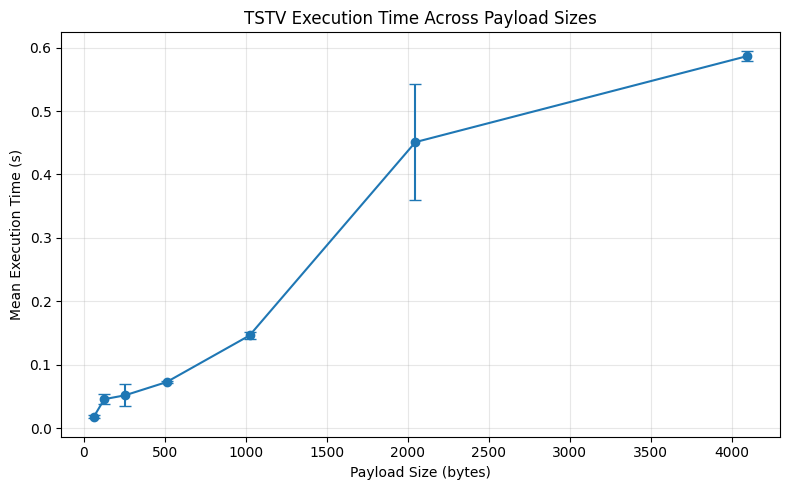

In [50]:
# Cell 35: Payload size vs. TSTV execution time

import matplotlib.pyplot as plt

x = payload_ci_df["Payload Size (bytes)"].to_numpy()
y = payload_ci_df["Mean Time (s)"].to_numpy()

lower = payload_ci_df["95% CI Lower (s)"].to_numpy()
upper = payload_ci_df["95% CI Upper (s)"].to_numpy()

# Calculate asymmetric error bars
lower_error = y - lower
upper_error = upper - y

plt.figure(figsize=(8, 5))

plt.errorbar(
    x,
    y,
    yerr=[lower_error, upper_error],
    marker="o",
    capsize=4,
    linewidth=1.5
)

plt.xlabel("Payload Size (bytes)")
plt.ylabel("Mean Execution Time (s)")
plt.title("TSTV Execution Time Across Payload Sizes")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [51]:
# Cell 36: Repeated user-load performance experiment

USER_LOAD_REPEATS = 10

user_load_results = []

for n in EXPERIMENT_USER_SIZES:

    print(f"Running {n}-user experiment...")

    for repeat in range(1, USER_LOAD_REPEATS + 1):

        # Run a fresh legitimate workload
        result = run_normal_experiment(n)

        # Mean transaction execution time for this trial
        mean_time = result["execution_time"].mean()

        # Standard deviation within this trial
        std_time = result["execution_time"].std(ddof=1)

        # Verification success
        verified_count = (
            result["tstv_status"] == "TSTV Verified"
        ).sum()

        total_count = len(result)

        verification_rate = (
            verified_count / total_count
            if total_count > 0 else 0
        )

        user_load_results.append({
            "Users": n,
            "Repeat": repeat,
            "Transactions": total_count,
            "Mean Execution Time (s)": mean_time,
            "Within-Trial SD (s)": std_time,
            "Verified Transactions": verified_count,
            "Verification Rate": verification_rate
        })

user_load_df = pd.DataFrame(user_load_results)

print("\nUser-load experiment completed.")

display(user_load_df)

Running 100-user experiment...
Running 200-user experiment...
Running 300-user experiment...
Running 400-user experiment...
Running 500-user experiment...

User-load experiment completed.


,Users,Repeat,Transactions,Mean Execution Time (s),Within-Trial SD (s),Verified Transactions,Verification Rate
0,100,1,100,0.007168,0.005123,100,1.0
1,100,2,100,0.003636,0.003792,100,1.0
2,100,3,100,0.002326,0.000153,100,1.0
3,100,4,100,0.002510,0.000526,100,1.0
4,100,5,100,0.002355,0.000183,100,1.0
5,100,6,100,0.002341,0.000223,100,1.0
6,100,7,100,0.004336,0.000614,100,1.0
7,100,8,100,0.004831,0.000787,100,1.0
8,100,9,100,0.004464,0.000284,100,1.0
9,100,10,100,0.004958,0.000574,100,1.0


In [52]:
# Cell 37: User-load performance statistics with 95% CI

from scipy import stats

user_load_summary = []

for n in EXPERIMENT_USER_SIZES:

    data = user_load_df[
        user_load_df["Users"] == n
    ]

    # These are the 10 independent trial means
    times = data["Mean Execution Time (s)"].to_numpy()

    trials = len(times)
    mean_time = np.mean(times)
    std_time = np.std(times, ddof=1)

    standard_error = std_time / np.sqrt(trials)

    t_critical = stats.t.ppf(
        0.975,
        df=trials - 1
    )

    margin_of_error = (
        t_critical * standard_error
    )

    ci_lower = mean_time - margin_of_error
    ci_upper = mean_time + margin_of_error

    verification_rate = data[
        "Verification Rate"
    ].mean()

    user_load_summary.append({
        "Users": n,
        "Trials": trials,
        "Mean Execution Time (s)": mean_time,
        "Between-Trial SD (s)": std_time,
        "95% CI Lower (s)": ci_lower,
        "95% CI Upper (s)": ci_upper,
        "Mean Verification Rate": verification_rate
    })

user_load_summary_df = pd.DataFrame(
    user_load_summary
)

display(user_load_summary_df)

print("\nUser-Load Performance Summary")
print("-----------------------------")

for _, row in user_load_summary_df.iterrows():

    print(
        f"{int(row['Users'])} users: "
        f"Mean={row['Mean Execution Time (s)']:.6f} s, "
        f"SD={row['Between-Trial SD (s)']:.6f} s, "
        f"95% CI="
        f"[{row['95% CI Lower (s)']:.6f}, "
        f"{row['95% CI Upper (s)']:.6f}], "
        f"Verification="
        f"{row['Mean Verification Rate']*100:.2f}%"
    )

,Users,Trials,Mean Execution Time (s),Between-Trial SD (s),95% CI Lower (s),95% CI Upper (s),Mean Verification Rate
0,100,10,0.003892,0.001580,0.002762,0.005023,1.0
1,200,10,0.002764,0.000717,0.002251,0.003277,1.0
2,300,10,0.003171,0.001627,0.002007,0.004335,1.0
3,400,10,0.002370,0.000027,0.002350,0.002390,1.0
4,500,10,0.002757,0.000728,0.002236,0.003278,1.0



User-Load Performance Summary
-----------------------------
100 users: Mean=0.003892 s, SD=0.001580 s, 95% CI=[0.002762, 0.005023], Verification=100.00%
200 users: Mean=0.002764 s, SD=0.000717 s, 95% CI=[0.002251, 0.003277], Verification=100.00%
300 users: Mean=0.003171 s, SD=0.001627 s, 95% CI=[0.002007, 0.004335], Verification=100.00%
400 users: Mean=0.002370 s, SD=0.000027 s, 95% CI=[0.002350, 0.002390], Verification=100.00%
500 users: Mean=0.002757 s, SD=0.000728 s, 95% CI=[0.002236, 0.003278], Verification=100.00%


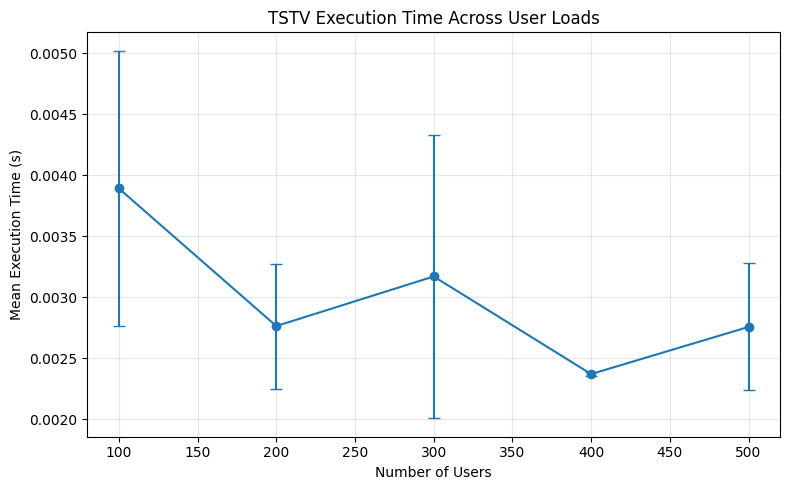

In [53]:
# Cell 38: User-load execution-time figure

import matplotlib.pyplot as plt

x = user_load_summary_df["Users"].to_numpy()
y = user_load_summary_df["Mean Execution Time (s)"].to_numpy()

lower = user_load_summary_df["95% CI Lower (s)"].to_numpy()
upper = user_load_summary_df["95% CI Upper (s)"].to_numpy()

# Asymmetric 95% CI error bars
lower_error = y - lower
upper_error = upper - y

plt.figure(figsize=(8, 5))

plt.errorbar(
    x,
    y,
    yerr=[lower_error, upper_error],
    marker="o",
    capsize=4,
    linewidth=1.5
)

plt.xlabel("Number of Users")
plt.ylabel("Mean Execution Time (s)")
plt.title("TSTV Execution Time Across User Loads")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [54]:
# Cell 39: Validate PRESENT-80 implementation against a standard test vector

TEST_KEY = 0x00000000000000000000
TEST_PLAINTEXT = 0x0000000000000000
EXPECTED_CIPHERTEXT = 0x5579C1387B228445

# Encrypt
test_ciphertext = present_encrypt_block(
    TEST_PLAINTEXT,
    TEST_KEY
)

# Decrypt
test_decrypted = present_decrypt_block(
    test_ciphertext,
    TEST_KEY
)

print("PRESENT-80 Test Vector")
print("----------------------")

print(f"Key:               {TEST_KEY:020X}")
print(f"Plaintext:         {TEST_PLAINTEXT:016X}")
print(f"Expected cipher:   {EXPECTED_CIPHERTEXT:016X}")
print(f"Computed cipher:   {test_ciphertext:016X}")
print(f"Decrypted plaintext: {test_decrypted:016X}")

encryption_match = (
    test_ciphertext == EXPECTED_CIPHERTEXT
)

decryption_match = (
    test_decrypted == TEST_PLAINTEXT
)

print("\nValidation")
print("----------")
print(f"Encryption test passed: {encryption_match}")
print(f"Decryption test passed: {decryption_match}")

if encryption_match and decryption_match:
    print("\nPRESENT-80 implementation validation PASSED.")
else:
    print("\nPRESENT-80 implementation validation FAILED.")

PRESENT-80 Test Vector
----------------------
Key:               00000000000000000000
Plaintext:         0000000000000000
Expected cipher:   5579C1387B228445
Computed cipher:   5579C1387B228445
Decrypted plaintext: 0000000000000000

Validation
----------
Encryption test passed: True
Decryption test passed: True

PRESENT-80 implementation validation PASSED.


In [55]:
# Cell 40: TSTV cryptographic workflow validation

print("TSTV Cryptographic Workflow")
print("===========================")

print("\n1. ECC Key Establishment")
print("   - Generate ECC key pairs")
print("   - Curve: SECP256R1")
print("   - Establish shared secret using ECDH")
print("   - Derive 256-bit session key using HKDF-SHA256")

print("\n2. PRESENT Encryption")
print("   - Derive 80-bit PRESENT key from the session key")
print("   - Encrypt IoT data using PRESENT-80")
print("   - Process data in 64-bit blocks")

print("\n3. Integrity Protection")
print("   - Derive HMAC key from the session key")
print("   - Generate HMAC-SHA256 over protected packet fields")

print("\n4. DCP Verification")
print("   - Verify source")
print("   - Verify destination")
print("   - Verify data flag")
print("   - Verify HMAC")
print("   - Verify TTL")

print("\n5. Decryption")
print("   - Decrypt only after successful DCP verification")

print("\nCryptographic workflow documented successfully.")

TSTV Cryptographic Workflow

1. ECC Key Establishment
   - Generate ECC key pairs
   - Curve: SECP256R1
   - Establish shared secret using ECDH
   - Derive 256-bit session key using HKDF-SHA256

2. PRESENT Encryption
   - Derive 80-bit PRESENT key from the session key
   - Encrypt IoT data using PRESENT-80
   - Process data in 64-bit blocks

3. Integrity Protection
   - Derive HMAC key from the session key
   - Generate HMAC-SHA256 over protected packet fields

4. DCP Verification
   - Verify source
   - Verify destination
   - Verify data flag
   - Verify HMAC
   - Verify TTL

5. Decryption
   - Decrypt only after successful DCP verification

Cryptographic workflow documented successfully.


In [56]:
# Cell 41: Registration-stage performance experiment

REGISTRATION_SIZES = [100, 200, 300, 400, 500]
REGISTRATION_REPEATS = 10

registration_results = []

for n in REGISTRATION_SIZES:

    print(f"Running registration experiment: {n} users...")

    for repeat in range(1, REGISTRATION_REPEATS + 1):

        start_time = time.perf_counter()

        registered_users = [
            create_experiment_user(i)
            for i in range(1, n + 1)
        ]

        end_time = time.perf_counter()

        execution_time = end_time - start_time

        successful = sum(
            user["registered"]
            for user in registered_users
        )

        registration_rate = (
            successful / n
            if n > 0 else 0
        )

        registration_results.append({
            "Users": n,
            "Repeat": repeat,
            "Registered Users": successful,
            "Registration Rate": registration_rate,
            "Total Execution Time (s)": execution_time,
            "Mean Time per User (s)": execution_time / n
        })

registration_df = pd.DataFrame(
    registration_results
)

print("\nRegistration experiment completed.")

display(registration_df)

Running registration experiment: 100 users...
Running registration experiment: 200 users...
Running registration experiment: 300 users...
Running registration experiment: 400 users...
Running registration experiment: 500 users...

Registration experiment completed.


,Users,Repeat,Registered Users,Registration Rate,Total Execution Time (s),Mean Time per User (s)
0,100,1,100,1.0,0.000361,0.000004
1,100,2,100,1.0,0.001467,0.000015
2,100,3,100,1.0,0.000332,0.000003
3,100,4,100,1.0,0.000325,0.000003
4,100,5,100,1.0,0.002642,0.000026
5,100,6,100,1.0,0.000334,0.000003
6,100,7,100,1.0,0.000343,0.000003
7,100,8,100,1.0,0.000330,0.000003
8,100,9,100,1.0,0.000328,0.000003
9,100,10,100,1.0,0.002369,0.000024


In [57]:
# Cell 42: Registration performance statistics with 95% CI

from scipy import stats

registration_summary = []

for n in REGISTRATION_SIZES:

    data = registration_df[
        registration_df["Users"] == n
    ]

    # Independent repeated-trial measurements
    times = data["Total Execution Time (s)"].to_numpy()

    trials = len(times)

    mean_total = np.mean(times)
    std_total = np.std(times, ddof=1)

    standard_error = std_total / np.sqrt(trials)

    t_critical = stats.t.ppf(
        0.975,
        df=trials - 1
    )

    margin_of_error = (
        t_critical * standard_error
    )

    ci_lower = mean_total - margin_of_error
    ci_upper = mean_total + margin_of_error

    # Per-user timing
    mean_per_user = (
        data["Mean Time per User (s)"].mean()
    )

    # Registration success
    registration_rate = (
        data["Registration Rate"].mean()
    )

    registration_summary.append({
        "Users": n,
        "Trials": trials,
        "Mean Total Time (s)": mean_total,
        "Between-Trial SD (s)": std_total,
        "95% CI Lower (s)": ci_lower,
        "95% CI Upper (s)": ci_upper,
        "Mean Time per User (s)": mean_per_user,
        "Registration Rate": registration_rate
    })

registration_summary_df = pd.DataFrame(
    registration_summary
)

display(registration_summary_df)

print("\nRegistration Performance Summary")
print("--------------------------------")

for _, row in registration_summary_df.iterrows():

    print(
        f"{int(row['Users'])} users: "
        f"Mean Total="
        f"{row['Mean Total Time (s)']:.6f} s, "
        f"SD="
        f"{row['Between-Trial SD (s)']:.6f} s, "
        f"95% CI="
        f"[{row['95% CI Lower (s)']:.6f}, "
        f"{row['95% CI Upper (s)']:.6f}], "
        f"Mean/User="
        f"{row['Mean Time per User (s)']:.9f} s, "
        f"Registration="
        f"{row['Registration Rate']*100:.2f}%"
    )

,Users,Trials,Mean Total Time (s),Between-Trial SD (s),95% CI Lower (s),95% CI Upper (s),Mean Time per User (s),Registration Rate
0,100,10,0.000883,0.000927,0.000220,0.001546,0.000009,1.0
1,200,10,0.001257,0.000853,0.000646,0.001867,0.000006,1.0
2,300,10,0.002015,0.001064,0.001254,0.002776,0.000007,1.0
3,400,10,0.001584,0.001044,0.000837,0.002331,0.000004,1.0
4,500,10,0.003432,0.002057,0.001961,0.004903,0.000007,1.0



Registration Performance Summary
--------------------------------
100 users: Mean Total=0.000883 s, SD=0.000927 s, 95% CI=[0.000220, 0.001546], Mean/User=0.000008831 s, Registration=100.00%
200 users: Mean Total=0.001257 s, SD=0.000853 s, 95% CI=[0.000646, 0.001867], Mean/User=0.000006284 s, Registration=100.00%
300 users: Mean Total=0.002015 s, SD=0.001064 s, 95% CI=[0.001254, 0.002776], Mean/User=0.000006715 s, Registration=100.00%
400 users: Mean Total=0.001584 s, SD=0.001044 s, 95% CI=[0.000837, 0.002331], Mean/User=0.000003960 s, Registration=100.00%
500 users: Mean Total=0.003432 s, SD=0.002057 s, 95% CI=[0.001961, 0.004903], Mean/User=0.000006864 s, Registration=100.00%


In [58]:
# Cell 43: UCP login/authentication performance experiment

UCP_SIZES = [100, 200, 300, 400, 500]
UCP_REPEATS = 10

ucp_results = []

for n in UCP_SIZES:

    print(f"Running UCP experiment: {n} users...")

    for repeat in range(1, UCP_REPEATS + 1):

        # Create registered users
        users = [
            create_experiment_user(i)
            for i in range(1, n + 1)
        ]

        start_time = time.perf_counter()

        verification_results = []

        for user in users:

            result = ucp_verification(
                user_record=user,
                username=user["username"],
                password=user["password"]
            )

            verification_results.append(result)

        end_time = time.perf_counter()

        execution_time = end_time - start_time

        # Count successful UCP verification
        successful = sum(
            result["status"] == "UCP Verified"
            for result in verification_results
        )

        verification_rate = (
            successful / n
            if n > 0 else 0
        )

        ucp_results.append({
            "Users": n,
            "Repeat": repeat,
            "Authentication Attempts": n,
            "UCP Verified": successful,
            "UCP Verification Rate": verification_rate,
            "Total Execution Time (s)": execution_time,
            "Mean Time per User (s)": execution_time / n
        })

ucp_df = pd.DataFrame(
    ucp_results
)

print("\nUCP experiment completed.")

display(ucp_df)

Running UCP experiment: 100 users...
Running UCP experiment: 200 users...
Running UCP experiment: 300 users...
Running UCP experiment: 400 users...
Running UCP experiment: 500 users...

UCP experiment completed.


,Users,Repeat,Authentication Attempts,UCP Verified,UCP Verification Rate,Total Execution Time (s),Mean Time per User (s)
0,100,1,100,100,1.0,0.003313,0.000033
1,100,2,100,100,1.0,0.002453,0.000025
2,100,3,100,100,1.0,0.002426,0.000024
3,100,4,100,100,1.0,0.000404,0.000004
4,100,5,100,100,1.0,0.000426,0.000004
5,100,6,100,100,1.0,0.000403,0.000004
6,100,7,100,100,1.0,0.004527,0.000045
7,100,8,100,100,1.0,0.000373,0.000004
8,100,9,100,100,1.0,0.000383,0.000004
9,100,10,100,100,1.0,0.000426,0.000004


In [59]:
from scipy import stats

ucp_summary = []

for n in UCP_SIZES:

    data = ucp_df[
        ucp_df["Users"] == n
    ]

    times = data[
        "Total Execution Time (s)"
    ].to_numpy()

    trials = len(times)

    mean_total = np.mean(times)
    std_total = np.std(times, ddof=1)

    standard_error = (
        std_total / np.sqrt(trials)
    )

    t_critical = stats.t.ppf(
        0.975,
        df=trials - 1
    )

    margin = (
        t_critical * standard_error
    )

    ci_lower = mean_total - margin
    ci_upper = mean_total + margin

    mean_per_user = data[
        "Mean Time per User (s)"
    ].mean()

    verification_rate = data[
        "UCP Verification Rate"
    ].mean()

    ucp_summary.append({
        "Users": n,
        "Trials": trials,
        "Mean Total Time (s)": mean_total,
        "Between-Trial SD (s)": std_total,
        "95% CI Lower (s)": ci_lower,
        "95% CI Upper (s)": ci_upper,
        "Mean Time per User (s)": mean_per_user,
        "UCP Verification Rate": verification_rate
    })

ucp_summary_df = pd.DataFrame(
    ucp_summary
)

display(
    ucp_summary_df.round(6)
)

print("\nUCP Authentication Performance Summary")

for _, row in ucp_summary_df.iterrows():
    print(
        f"{int(row['Users'])} users: "
        f"Mean Total={row['Mean Total Time (s)']:.6f} s, "
        f"SD={row['Between-Trial SD (s)']:.6f} s, "
        f"95% CI=["
        f"{row['95% CI Lower (s)']:.6f}, "
        f"{row['95% CI Upper (s)']:.6f}], "
        f"Mean/User={row['Mean Time per User (s)']:.9f} s, "
        f"UCP Verification="
        f"{row['UCP Verification Rate']*100:.2f}%"
    )

,Users,Trials,Mean Total Time (s),Between-Trial SD (s),95% CI Lower (s),95% CI Upper (s),Mean Time per User (s),UCP Verification Rate
0,100,10,0.001513,0.001544,0.000409,0.002618,0.000015,1.0
1,200,10,0.002147,0.002370,0.000452,0.003842,0.000011,1.0
2,300,10,0.004681,0.002516,0.002881,0.006481,0.000016,1.0
3,400,10,0.005249,0.002536,0.003435,0.007063,0.000013,1.0
4,500,10,0.005901,0.002830,0.003877,0.007925,0.000012,1.0



UCP Authentication Performance Summary
100 users: Mean Total=0.001513 s, SD=0.001544 s, 95% CI=[0.000409, 0.002618], Mean/User=0.000015133 s, UCP Verification=100.00%
200 users: Mean Total=0.002147 s, SD=0.002370 s, 95% CI=[0.000452, 0.003842], Mean/User=0.000010735 s, UCP Verification=100.00%
300 users: Mean Total=0.004681 s, SD=0.002516 s, 95% CI=[0.002881, 0.006481], Mean/User=0.000015604 s, UCP Verification=100.00%
400 users: Mean Total=0.005249 s, SD=0.002536 s, 95% CI=[0.003435, 0.007063], Mean/User=0.000013123 s, UCP Verification=100.00%
500 users: Mean Total=0.005901 s, SD=0.002830 s, 95% CI=[0.003877, 0.007925], Mean/User=0.000011802 s, UCP Verification=100.00%


In [66]:


# Cell 45: DCP / cloud-side secure transaction verification experiment

DCP_SIZES = [100, 200, 300, 400, 500]
DCP_REPEATS = 10

dcp_results = []

# Cloud ECC key pair
cloud_private_key, cloud_public_key = generate_ecc_key_pair()

for n in DCP_SIZES:

    print(f"Running DCP experiment: {n} users...")

    for repeat in range(1, DCP_REPEATS + 1):

        # Create registered legitimate users
        users = [
            create_experiment_user(i)
            for i in range(1, n + 1)
        ]

        # ---------------------------------------------------------
        # Prepare secure packets BEFORE timing DCP verification.
        # Each user has an independent ECC-derived session key.
        # ---------------------------------------------------------
        prepared_packets = []

        for user in users:

            # Independent user ECC key pair
            user_private_key, user_public_key = generate_ecc_key_pair()

            # Independent session key
            session_key = derive_shared_key(
                user_private_key,
                cloud_public_key
            )

            # Derive PRESENT key
            present_key = derive_present_key(
                session_key
            )

            # Derive HMAC key
            mac_key = hashlib.sha256(
                b"TSTV-HMAC-" + session_key
            ).digest()

            # Create secure packet using the existing function
            packet = create_secure_tstv_packet(
                user["username"],
                "cloud",
                f"Secure IoT data from user {user['user_id']}",
                present_key,
                mac_key,
                ttl=300
            )

            prepared_packets.append({
                "user": user,
                "packet": packet,
                "mac_key": mac_key
            })

        # ---------------------------------------------------------
        # Time ONLY DCP verification.
        # ---------------------------------------------------------
        start_time = time.perf_counter()

        verification_results = []

        for item in prepared_packets:

            result = dcp_secure_verification(
                item["packet"],
                item["user"]["username"],
                "cloud",
                item["mac_key"]
            )

            verification_results.append(result)

        end_time = time.perf_counter()

        execution_time = end_time - start_time

        # Count successful DCP verification
        successful = sum(
            result["status"] == "DCP Verified"
            for result in verification_results
        )

        verification_rate = successful / n

        dcp_results.append({
            "Users": n,
            "Repeat": repeat,
            "Transactions": n,
            "DCP Verified": successful,
            "DCP Verification Rate": verification_rate,
            "Total Execution Time (s)": execution_time,
            "Mean Time per Transaction (s)": execution_time / n
        })

dcp_df = pd.DataFrame(dcp_results)

print("\nDCP experiment completed.")

display(dcp_df)

Running DCP experiment: 100 users...
Running DCP experiment: 200 users...
Running DCP experiment: 300 users...
Running DCP experiment: 400 users...
Running DCP experiment: 500 users...

DCP experiment completed.


,Users,Repeat,Transactions,DCP Verified,DCP Verification Rate,Total Execution Time (s),Mean Time per Transaction (s)
0,100,1,100,100,1.0,0.009100,0.000091
1,100,2,100,100,1.0,0.003019,0.000030
2,100,3,100,100,1.0,0.003253,0.000033
3,100,4,100,100,1.0,0.005115,0.000051
4,100,5,100,100,1.0,0.002950,0.000030
5,100,6,100,100,1.0,0.006072,0.000061
6,100,7,100,100,1.0,0.001601,0.000016
7,100,8,100,100,1.0,0.001684,0.000017
8,100,9,100,100,1.0,0.002016,0.000020
9,100,10,100,100,1.0,0.001800,0.000018


In [61]:
import inspect

print(inspect.signature(create_secure_tstv_packet))

(source, destination, data, present_key, mac_key, ttl=300)


In [62]:
print(inspect.getsource(create_secure_tstv_packet))

def create_secure_tstv_packet(
    source,
    destination,
    data,
    present_key,
    mac_key,
    ttl=300
):
    """
    Create a secure TSTV data packet.

    Processing:
        1. Encrypt application data using PRESENT-80
        2. Add source and destination
        3. Add timestamp and TTL
        4. Add data flag
        5. Generate keyed HMAC-SHA256
    """

    # --------------------------------------------------------
    # 1. Encrypt application data
    # --------------------------------------------------------

    encrypted_blocks = present_encrypt_data(
        data,
        present_key
    )

    # --------------------------------------------------------
    # 2. Create packet metadata
    # --------------------------------------------------------

    packet = {
        "source": source,
        "destination": destination,
        "encrypted_data": [
            hex(block) for block in encrypted_blocks
        ],
        "timestamp": time.time(),
        "ttl": tt

In [64]:
import inspect

print(inspect.signature(dcp_secure_verification))

(packet, expected_source, expected_destination, mac_key)


In [65]:
print(inspect.getsource(dcp_secure_verification))

def dcp_secure_verification(
    packet,
    expected_source,
    expected_destination,
    mac_key
):
    """
    DCP verification for the secure TSTV packet.

    Checks independently:
        - source
        - destination
        - data flag
        - HMAC
        - TTL
    """

    result = {
        "source_verified": False,
        "destination_verified": False,
        "data_flag_verified": False,
        "hmac_verified": False,
        "ttl_verified": False,
        "status": "DCP Rejected"
    }

    # --------------------------------------------------------
    # Source verification
    # --------------------------------------------------------

    result["source_verified"] = (
        packet.get("source") == expected_source
    )

    # --------------------------------------------------------
    # Destination verification
    # --------------------------------------------------------

    result["destination_verified"] = (
        packet.get("destination") == expected_des

In [67]:
from scipy import stats

dcp_summary = []

for n in DCP_SIZES:

    data = dcp_df[
        dcp_df["Users"] == n
    ]

    times = data[
        "Total Execution Time (s)"
    ].to_numpy()

    trials = len(times)

    mean_total = np.mean(times)
    std_total = np.std(times, ddof=1)

    standard_error = (
        std_total / np.sqrt(trials)
    )

    t_critical = stats.t.ppf(
        0.975,
        df=trials - 1
    )

    margin = (
        t_critical * standard_error
    )

    ci_lower = mean_total - margin
    ci_upper = mean_total + margin

    mean_per_transaction = data[
        "Mean Time per Transaction (s)"
    ].mean()

    verification_rate = data[
        "DCP Verification Rate"
    ].mean()

    dcp_summary.append({
        "Users": n,
        "Trials": trials,
        "Mean Total Time (s)": mean_total,
        "Between-Trial SD (s)": std_total,
        "95% CI Lower (s)": ci_lower,
        "95% CI Upper (s)": ci_upper,
        "Mean Time per Transaction (s)": mean_per_transaction,
        "DCP Verification Rate": verification_rate
    })

dcp_summary_df = pd.DataFrame(
    dcp_summary
)

display(
    dcp_summary_df.round(6)
)

print("\nDCP Verification Performance Summary")

for _, row in dcp_summary_df.iterrows():
    print(
        f"{int(row['Users'])} users: "
        f"Mean Total={row['Mean Total Time (s)']:.6f} s, "
        f"SD={row['Between-Trial SD (s)']:.6f} s, "
        f"95% CI=["
        f"{row['95% CI Lower (s)']:.6f}, "
        f"{row['95% CI Upper (s)']:.6f}], "
        f"Mean/Transaction="
        f"{row['Mean Time per Transaction (s)']:.9f} s, "
        f"DCP Verification="
        f"{row['DCP Verification Rate']*100:.2f}%"
    )

,Users,Trials,Mean Total Time (s),Between-Trial SD (s),95% CI Lower (s),95% CI Upper (s),Mean Time per Transaction (s),DCP Verification Rate
0,100,10,0.003661,0.002425,0.001927,0.005395,0.000037,1.0
1,200,10,0.005115,0.002044,0.003653,0.006577,0.000026,1.0
2,300,10,0.004827,0.000253,0.004646,0.005008,0.000016,1.0
3,400,10,0.007495,0.002217,0.005909,0.009081,0.000019,1.0
4,500,10,0.009189,0.002216,0.007604,0.010774,0.000018,1.0



DCP Verification Performance Summary
100 users: Mean Total=0.003661 s, SD=0.002425 s, 95% CI=[0.001927, 0.005395], Mean/Transaction=0.000036610 s, DCP Verification=100.00%
200 users: Mean Total=0.005115 s, SD=0.002044 s, 95% CI=[0.003653, 0.006577], Mean/Transaction=0.000025574 s, DCP Verification=100.00%
300 users: Mean Total=0.004827 s, SD=0.000253 s, 95% CI=[0.004646, 0.005008], Mean/Transaction=0.000016089 s, DCP Verification=100.00%
400 users: Mean Total=0.007495 s, SD=0.002217 s, 95% CI=[0.005909, 0.009081], Mean/Transaction=0.000018737 s, DCP Verification=100.00%
500 users: Mean Total=0.009189 s, SD=0.002216 s, 95% CI=[0.007604, 0.010774], Mean/Transaction=0.000018379 s, DCP Verification=100.00%


In [68]:
# Cell 47: Inspect the existing end-to-end TSTV function

import inspect

print("Function signature:")
print(inspect.signature(tstv_secure_transaction))

print("\nFunction source:")
print(inspect.getsource(tstv_secure_transaction))

Function signature:
(user_record, username, password, source, destination, data, expected_source, expected_destination, session_key, ttl=300)

Function source:
def tstv_secure_transaction(
    user_record,
    username,
    password,
    source,
    destination,
    data,
    expected_source,
    expected_destination,
    session_key,
    ttl=300
):
    """
    Complete TSTV secure transaction.

    Stage 1:
        UCP
        - Credential verification
        - Authentication
        - Authorization

    Cryptographic layer:
        - ECC-derived session key
        - PRESENT-80 data encryption
        - HMAC-SHA256 packet integrity

    Stage 2:
        DCP
        - Source verification
        - Destination verification
        - Data-flag verification
        - HMAC verification
        - TTL verification

    Final:
        Data is decrypted only when UCP and DCP succeed.
    """

    # ========================================================
    # STAGE 1 — UCP
    # ===========

In [69]:
# Cell 48: End-to-end TSTV performance experiment
#
# Measures the complete TSTV transaction:
# UCP -> cryptographic processing -> DCP -> decryption
#
# Each user receives an independent ECC-derived session key.

TSTV_SIZES = [100, 200, 300, 400, 500]
TSTV_REPEATS = 10

tstv_results = []

# Cloud ECC key pair
cloud_private_key, cloud_public_key = generate_ecc_key_pair()

for n in TSTV_SIZES:

    print(f"Running end-to-end TSTV experiment: {n} users...")

    for repeat in range(1, TSTV_REPEATS + 1):

        # ---------------------------------------------------------
        # Create registered legitimate users
        # ---------------------------------------------------------
        users = [
            create_experiment_user(i)
            for i in range(1, n + 1)
        ]

        # ---------------------------------------------------------
        # Prepare an independent ECC session key for every user.
        # Key establishment is performed BEFORE the timed
        # transaction loop so that the benchmark focuses on the
        # implemented TSTV transaction workflow.
        # ---------------------------------------------------------
        user_sessions = []

        for user in users:

            user_private_key, user_public_key = generate_ecc_key_pair()

            session_key = derive_shared_key(
                user_private_key,
                cloud_public_key
            )

            user_sessions.append({
                "user": user,
                "session_key": session_key
            })

        # ---------------------------------------------------------
        # End-to-end TSTV timing
        # ---------------------------------------------------------
        start_time = time.perf_counter()

        verification_results = []

        for item in user_sessions:

            user = item["user"]
            session_key = item["session_key"]

            result = tstv_secure_transaction(
                user_record=user,
                username=user["username"],
                password=user["password"],
                source=user["username"],
                destination="cloud",
                data=f"Secure IoT data from user {user['user_id']}",
                expected_source=user["username"],
                expected_destination="cloud",
                session_key=session_key,
                ttl=300
            )

            verification_results.append(result)

        end_time = time.perf_counter()

        execution_time = end_time - start_time

        # ---------------------------------------------------------
        # Count successful complete TSTV transactions
        # ---------------------------------------------------------
        successful = sum(
            result["tstv_status"] == "TSTV Verified"
            for result in verification_results
        )

        verification_rate = successful / n

        tstv_results.append({
            "Users": n,
            "Repeat": repeat,
            "Transactions": n,
            "TSTV Verified": successful,
            "TSTV Verification Rate": verification_rate,
            "Total Execution Time (s)": execution_time,
            "Mean Time per Transaction (s)": execution_time / n
        })

tstv_df = pd.DataFrame(tstv_results)

print("\nEnd-to-end TSTV experiment completed.")

display(tstv_df)

Running end-to-end TSTV experiment: 100 users...
Running end-to-end TSTV experiment: 200 users...
Running end-to-end TSTV experiment: 300 users...
Running end-to-end TSTV experiment: 400 users...
Running end-to-end TSTV experiment: 500 users...

End-to-end TSTV experiment completed.


,Users,Repeat,Transactions,TSTV Verified,TSTV Verification Rate,Total Execution Time (s),Mean Time per Transaction (s)
0,100,1,100,100,1.0,0.483541,0.004835
1,100,2,100,100,1.0,0.486759,0.004868
2,100,3,100,100,1.0,0.459631,0.004596
3,100,4,100,100,1.0,0.489610,0.004896
4,100,5,100,100,1.0,0.467517,0.004675
5,100,6,100,100,1.0,0.482872,0.004829
6,100,7,100,100,1.0,0.831092,0.008311
7,100,8,100,100,1.0,0.940931,0.009409
8,100,9,100,100,1.0,0.936831,0.009368
9,100,10,100,100,1.0,0.775774,0.007758


In [70]:
# Cell 49: End-to-end TSTV statistical summary

from scipy import stats

tstv_summary = []

for n in TSTV_SIZES:

    data = tstv_df[
        tstv_df["Users"] == n
    ]

    times = data[
        "Total Execution Time (s)"
    ].to_numpy()

    trials = len(times)

    mean_total = np.mean(times)
    std_total = np.std(times, ddof=1)

    standard_error = (
        std_total / np.sqrt(trials)
    )

    t_critical = stats.t.ppf(
        0.975,
        df=trials - 1
    )

    margin = (
        t_critical * standard_error
    )

    ci_lower = mean_total - margin
    ci_upper = mean_total + margin

    mean_per_transaction = data[
        "Mean Time per Transaction (s)"
    ].mean()

    verification_rate = data[
        "TSTV Verification Rate"
    ].mean()

    tstv_summary.append({
        "Users": n,
        "Trials": trials,
        "Mean Total Time (s)": mean_total,
        "Between-Trial SD (s)": std_total,
        "95% CI Lower (s)": ci_lower,
        "95% CI Upper (s)": ci_upper,
        "Mean Time per Transaction (s)": mean_per_transaction,
        "TSTV Verification Rate": verification_rate
    })

tstv_summary_df = pd.DataFrame(
    tstv_summary
)

display(
    tstv_summary_df.round(6)
)

print("\nEnd-to-End TSTV Performance Summary")

for _, row in tstv_summary_df.iterrows():

    print(
        f"{int(row['Users'])} users: "
        f"Mean Total={row['Mean Total Time (s)']:.6f} s, "
        f"SD={row['Between-Trial SD (s)']:.6f} s, "
        f"95% CI=["
        f"{row['95% CI Lower (s)']:.6f}, "
        f"{row['95% CI Upper (s)']:.6f}], "
        f"Mean/Transaction="
        f"{row['Mean Time per Transaction (s)']:.9f} s, "
        f"TSTV Verification="
        f"{row['TSTV Verification Rate']*100:.2f}%"
    )

,Users,Trials,Mean Total Time (s),Between-Trial SD (s),95% CI Lower (s),95% CI Upper (s),Mean Time per Transaction (s),TSTV Verification Rate
0,100,10,0.635456,0.208424,0.486359,0.784553,0.006355,1.0
1,200,10,0.958405,0.018373,0.945262,0.971548,0.004792,1.0
2,300,10,1.738501,0.562345,1.336223,2.140778,0.005795,1.0
3,400,10,2.075415,0.364042,1.814995,2.335835,0.005189,1.0
4,500,10,2.908717,0.754882,2.368707,3.448727,0.005817,1.0



End-to-End TSTV Performance Summary
100 users: Mean Total=0.635456 s, SD=0.208424 s, 95% CI=[0.486359, 0.784553], Mean/Transaction=0.006354559 s, TSTV Verification=100.00%
200 users: Mean Total=0.958405 s, SD=0.018373 s, 95% CI=[0.945262, 0.971548], Mean/Transaction=0.004792025 s, TSTV Verification=100.00%
300 users: Mean Total=1.738501 s, SD=0.562345 s, 95% CI=[1.336223, 2.140778], Mean/Transaction=0.005795003 s, TSTV Verification=100.00%
400 users: Mean Total=2.075415 s, SD=0.364042 s, 95% CI=[1.814995, 2.335835], Mean/Transaction=0.005188538 s, TSTV Verification=100.00%
500 users: Mean Total=2.908717 s, SD=0.754882 s, 95% CI=[2.368707, 3.448727], Mean/Transaction=0.005817433 s, TSTV Verification=100.00%


In [71]:
# Cell 50: Inspect the secure TSTV packet structure

test_user = create_experiment_user(1)

test_private_key, test_public_key = generate_ecc_key_pair()

test_session_key = derive_shared_key(
    test_private_key,
    cloud_public_key
)

test_present_key = derive_present_key(
    test_session_key
)

test_mac_key = hashlib.sha256(
    b"TSTV-HMAC-" + test_session_key
).digest()

test_packet = create_secure_tstv_packet(
    test_user["username"],
    "cloud",
    "Test IoT data",
    test_present_key,
    test_mac_key,
    ttl=300
)

print("Secure packet structure:")
print(test_packet)

print("\nPacket keys:")
print(list(test_packet.keys()))

Secure packet structure:
{'source': 'user_1', 'destination': 'cloud', 'encrypted_data': ['0x1f87ddbf5f253022', '0x6b9efcd99091e837'], 'timestamp': 1791184893.361086, 'ttl': 300, 'data_flag': True, 'hmac': 'a19625273a596c4f046a3f648de9feeb9b29369d3d8be3ea84f21ec24e1c44bd'}

Packet keys:
['source', 'destination', 'encrypted_data', 'timestamp', 'ttl', 'data_flag', 'hmac']


In [72]:
# Cell 51: Systematic security-validation experiment
#
# Tests the security checks implemented in the actual TSTV code:
# 1. Invalid credentials
# 2. Unauthorized user
# 3. Invalid source
# 4. Invalid destination
# 5. Tampered encrypted data
# 6. Forged/modified HMAC
# 7. Invalid data flag
# 8. Expired TTL

import copy
import time

security_results = []

# ---------------------------------------------------------
# Prepare a legitimate test user and cryptographic context
# ---------------------------------------------------------

test_user = create_experiment_user(1)

test_private_key, test_public_key = generate_ecc_key_pair()

test_session_key = derive_shared_key(
    test_private_key,
    cloud_public_key
)

test_present_key = derive_present_key(
    test_session_key
)

test_mac_key = hashlib.sha256(
    b"TSTV-HMAC-" + test_session_key
).digest()

# ---------------------------------------------------------
# Create a legitimate packet
# ---------------------------------------------------------

legitimate_packet = create_secure_tstv_packet(
    test_user["username"],
    "cloud",
    "Secure IoT data",
    test_present_key,
    test_mac_key,
    ttl=300
)

# =========================================================
# Attack 1 — Invalid credentials
# =========================================================

result = ucp_verification(
    test_user,
    test_user["username"],
    "WRONG_PASSWORD"
)

security_results.append({
    "Attack": "Invalid credentials",
    "Expected Detection Stage": "UCP",
    "Detection Check": "Credential verification",
    "Observed Status": result["status"],
    "Detected": result["status"] != "UCP Verified"
})

# =========================================================
# Attack 2 — Unauthorized user
# =========================================================

unauthorized_user = copy.deepcopy(test_user)
unauthorized_user["authorized"] = False

result = ucp_verification(
    unauthorized_user,
    unauthorized_user["username"],
    unauthorized_user["password"]
)

security_results.append({
    "Attack": "Unauthorized user",
    "Expected Detection Stage": "UCP",
    "Detection Check": "Authorization",
    "Observed Status": result["status"],
    "Detected": result["status"] != "UCP Verified"
})

# =========================================================
# Attack 3 — Invalid source
# =========================================================

packet = copy.deepcopy(legitimate_packet)

result = dcp_secure_verification(
    packet,
    "attacker_source",
    "cloud",
    test_mac_key
)

security_results.append({
    "Attack": "Invalid source",
    "Expected Detection Stage": "DCP",
    "Detection Check": "Source verification",
    "Observed Status": result["status"],
    "Detected": result["status"] != "DCP Verified"
})

# =========================================================
# Attack 4 — Invalid destination
# =========================================================

packet = copy.deepcopy(legitimate_packet)

result = dcp_secure_verification(
    packet,
    test_user["username"],
    "attacker_destination",
    test_mac_key
)

security_results.append({
    "Attack": "Invalid destination",
    "Expected Detection Stage": "DCP",
    "Detection Check": "Destination verification",
    "Observed Status": result["status"],
    "Detected": result["status"] != "DCP Verified"
})

# =========================================================
# Attack 5 — Tampered encrypted data
# =========================================================

packet = copy.deepcopy(legitimate_packet)

# Modify the first encrypted block
original_block = packet["encrypted_data"][0]

if original_block != "0x0000000000000000":
    packet["encrypted_data"][0] = "0x0000000000000000"
else:
    packet["encrypted_data"][0] = "0xFFFFFFFFFFFFFFFF"

result = dcp_secure_verification(
    packet,
    test_user["username"],
    "cloud",
    test_mac_key
)

security_results.append({
    "Attack": "Tampered encrypted data",
    "Expected Detection Stage": "DCP",
    "Detection Check": "HMAC verification",
    "Observed Status": result["status"],
    "Detected": result["status"] != "DCP Verified"
})

# =========================================================
# Attack 6 — Forged / modified HMAC
# =========================================================

packet = copy.deepcopy(legitimate_packet)

# Change the HMAC without changing the encrypted data
packet["hmac"] = (
    "0" * len(packet["hmac"])
)

result = dcp_secure_verification(
    packet,
    test_user["username"],
    "cloud",
    test_mac_key
)

security_results.append({
    "Attack": "Forged/modified HMAC",
    "Expected Detection Stage": "DCP",
    "Detection Check": "HMAC verification",
    "Observed Status": result["status"],
    "Detected": result["status"] != "DCP Verified"
})

# =========================================================
# Attack 7 — Invalid data flag
# =========================================================

packet = copy.deepcopy(legitimate_packet)

packet["data_flag"] = False

result = dcp_secure_verification(
    packet,
    test_user["username"],
    "cloud",
    test_mac_key
)

security_results.append({
    "Attack": "Invalid data flag",
    "Expected Detection Stage": "DCP",
    "Detection Check": "Data-flag verification",
    "Observed Status": result["status"],
    "Detected": result["status"] != "DCP Verified"
})

# =========================================================
# Attack 8 — Expired TTL
# =========================================================

packet = copy.deepcopy(legitimate_packet)

# Make timestamp old enough to exceed the 300-second TTL
packet["timestamp"] = time.time() - 1000

result = dcp_secure_verification(
    packet,
    test_user["username"],
    "cloud",
    test_mac_key
)

security_results.append({
    "Attack": "Expired TTL",
    "Expected Detection Stage": "DCP",
    "Detection Check": "TTL/timestamp verification",
    "Observed Status": result["status"],
    "Detected": result["status"] != "DCP Verified"
})

# =========================================================
# Create final security-validation table
# =========================================================

security_validation_df = pd.DataFrame(
    security_results
)

display(security_validation_df)

# ---------------------------------------------------------
# Overall detection result
# ---------------------------------------------------------

total_attacks = len(security_validation_df)
detected_attacks = security_validation_df["Detected"].sum()
detection_rate = detected_attacks / total_attacks

print("\nSecurity Validation Summary")
print(f"Attack scenarios tested: {total_attacks}")
print(f"Attack scenarios detected: {detected_attacks}")
print(f"Detection rate: {detection_rate * 100:.2f}%")

,Attack,Expected Detection Stage,Detection Check,Observed Status,Detected
0,Invalid credentials,UCP,Credential verification,Rejected - Credential mismatch,True
1,Unauthorized user,UCP,Authorization,Rejected - Unauthorized user,True
2,Invalid source,DCP,Source verification,DCP Rejected,True
3,Invalid destination,DCP,Destination verification,DCP Rejected,True
4,Tampered encrypted data,DCP,HMAC verification,DCP Rejected,True
5,Forged/modified HMAC,DCP,HMAC verification,DCP Rejected,True
6,Invalid data flag,DCP,Data-flag verification,DCP Rejected,True
7,Expired TTL,DCP,TTL/timestamp verification,DCP Rejected,True



Security Validation Summary
Attack scenarios tested: 8
Attack scenarios detected: 8
Detection rate: 100.00%


In [73]:
# Cell 52: ECC/ECDH session-key establishment overhead experiment
#
# Measures the time required to establish an independent ECC-derived
# session key for each user.
#
# This is measured separately from the TSTV transaction itself.

ECC_SIZES = [100, 200, 300, 400, 500]
ECC_REPEATS = 10

ecc_results = []

for n in ECC_SIZES:

    print(f"Running ECC/ECDH experiment: {n} users...")

    for repeat in range(1, ECC_REPEATS + 1):

        # ---------------------------------------------------------
        # Generate one cloud key pair before timing.
        # ---------------------------------------------------------
        cloud_private_key, cloud_public_key = generate_ecc_key_pair()

        # Generate independent user key pairs before timing.
        # Key-pair generation is deliberately excluded so that
        # this experiment measures ECDH session-key derivation.
        user_key_pairs = []

        for _ in range(n):

            user_private_key, user_public_key = generate_ecc_key_pair()

            user_key_pairs.append({
                "private_key": user_private_key,
                "public_key": user_public_key
            })

        # ---------------------------------------------------------
        # Time only ECDH + HKDF session-key derivation.
        # ---------------------------------------------------------
        start_time = time.perf_counter()

        session_keys = []

        for item in user_key_pairs:

            session_key = derive_shared_key(
                item["private_key"],
                cloud_public_key
            )

            session_keys.append(session_key)

        end_time = time.perf_counter()

        execution_time = end_time - start_time

        # ---------------------------------------------------------
        # Validate that every session key was generated correctly.
        # ---------------------------------------------------------
        valid_keys = sum(
            isinstance(key, bytes) and len(key) == 32
            for key in session_keys
        )

        key_generation_rate = valid_keys / n

        ecc_results.append({
            "Users": n,
            "Repeat": repeat,
            "Session Keys Generated": valid_keys,
            "Session-Key Generation Rate": key_generation_rate,
            "Total ECDH/HKDF Time (s)": execution_time,
            "Mean Time per Session Key (s)": execution_time / n
        })

ecc_df = pd.DataFrame(ecc_results)

print("\nECC/ECDH session-key experiment completed.")

display(ecc_df)

Running ECC/ECDH experiment: 100 users...
Running ECC/ECDH experiment: 200 users...
Running ECC/ECDH experiment: 300 users...
Running ECC/ECDH experiment: 400 users...
Running ECC/ECDH experiment: 500 users...

ECC/ECDH session-key experiment completed.


,Users,Repeat,Session Keys Generated,Session-Key Generation Rate,Total ECDH/HKDF Time (s),Mean Time per Session Key (s)
0,100,1,100,1.0,0.064761,0.000648
1,100,2,100,1.0,0.051595,0.000516
2,100,3,100,1.0,0.062958,0.000630
3,100,4,100,1.0,0.049722,0.000497
4,100,5,100,1.0,0.036633,0.000366
5,100,6,100,1.0,0.044650,0.000446
6,100,7,100,1.0,0.041377,0.000414
7,100,8,100,1.0,0.054194,0.000542
8,100,9,100,1.0,0.051513,0.000515
9,100,10,100,1.0,0.066325,0.000663


In [74]:
# Cell 53: ECC/ECDH session-key establishment statistical summary

from scipy import stats

ecc_summary = []

for n in ECC_SIZES:

    data = ecc_df[
        ecc_df["Users"] == n
    ]

    times = data[
        "Total ECDH/HKDF Time (s)"
    ].to_numpy()

    trials = len(times)

    mean_total = np.mean(times)
    std_total = np.std(times, ddof=1)

    standard_error = (
        std_total / np.sqrt(trials)
    )

    t_critical = stats.t.ppf(
        0.975,
        df=trials - 1
    )

    margin = (
        t_critical * standard_error
    )

    ci_lower = mean_total - margin
    ci_upper = mean_total + margin

    mean_per_session = data[
        "Mean Time per Session Key (s)"
    ].mean()

    generation_rate = data[
        "Session-Key Generation Rate"
    ].mean()

    ecc_summary.append({
        "Users": n,
        "Trials": trials,
        "Mean Total ECDH/HKDF Time (s)": mean_total,
        "Between-Trial SD (s)": std_total,
        "95% CI Lower (s)": ci_lower,
        "95% CI Upper (s)": ci_upper,
        "Mean Time per Session Key (s)": mean_per_session,
        "Session-Key Generation Rate": generation_rate
    })

ecc_summary_df = pd.DataFrame(
    ecc_summary
)

display(
    ecc_summary_df.round(6)
)

print("\nECC/ECDH Session-Key Establishment Summary")

for _, row in ecc_summary_df.iterrows():

    print(
        f"{int(row['Users'])} users: "
        f"Mean Total={row['Mean Total ECDH/HKDF Time (s)']:.6f} s, "
        f"SD={row['Between-Trial SD (s)']:.6f} s, "
        f"95% CI=["
        f"{row['95% CI Lower (s)']:.6f}, "
        f"{row['95% CI Upper (s)']:.6f}], "
        f"Mean/Session="
        f"{row['Mean Time per Session Key (s)']:.9f} s, "
        f"Generation="
        f"{row['Session-Key Generation Rate']*100:.2f}%"
    )

,Users,Trials,Mean Total ECDH/HKDF Time (s),Between-Trial SD (s),95% CI Lower (s),95% CI Upper (s),Mean Time per Session Key (s),Session-Key Generation Rate
0,100,10,0.052373,0.010001,0.045219,0.059527,0.000524,1.0
1,200,10,0.071217,0.011989,0.062641,0.079794,0.000356,1.0
2,300,10,0.065299,0.019950,0.051028,0.079570,0.000218,1.0
3,400,10,0.055190,0.025011,0.037299,0.073082,0.000138,1.0
4,500,10,0.046749,0.004898,0.043245,0.050253,0.000093,1.0



ECC/ECDH Session-Key Establishment Summary
100 users: Mean Total=0.052373 s, SD=0.010001 s, 95% CI=[0.045219, 0.059527], Mean/Session=0.000523728 s, Generation=100.00%
200 users: Mean Total=0.071217 s, SD=0.011989 s, 95% CI=[0.062641, 0.079794], Mean/Session=0.000356085 s, Generation=100.00%
300 users: Mean Total=0.065299 s, SD=0.019950 s, 95% CI=[0.051028, 0.079570], Mean/Session=0.000217663 s, Generation=100.00%
400 users: Mean Total=0.055190 s, SD=0.025011 s, 95% CI=[0.037299, 0.073082], Mean/Session=0.000137976 s, Generation=100.00%
500 users: Mean Total=0.046749 s, SD=0.004898 s, 95% CI=[0.043245, 0.050253], Mean/Session=0.000093498 s, Generation=100.00%


In [75]:
# Cell 54: Consolidate all major performance results
#
# Combines the completed summary dataframes into one
# publication-ready master performance table.

# ---------------------------------------------------------
# Prepare registration summary
# ---------------------------------------------------------

registration_master = registration_summary_df[
    [
        "Users",
        "Trials",
        "Mean Total Time (s)",
        "Between-Trial SD (s)",
        "95% CI Lower (s)",
        "95% CI Upper (s)",
        "Mean Time per User (s)",
        "Registration Rate"
    ]
].copy()

registration_master["Experiment"] = "Registration"
registration_master["Verification Rate"] = (
    registration_master["Registration Rate"]
)

registration_master["Mean Time per Transaction (s)"] = (
    registration_master["Mean Time per User (s)"]
)

# ---------------------------------------------------------
# Prepare UCP summary
# ---------------------------------------------------------

ucp_master = ucp_summary_df[
    [
        "Users",
        "Trials",
        "Mean Total Time (s)",
        "Between-Trial SD (s)",
        "95% CI Lower (s)",
        "95% CI Upper (s)",
        "Mean Time per User (s)",
        "UCP Verification Rate"
    ]
].copy()

ucp_master["Experiment"] = "UCP Authentication"
ucp_master["Verification Rate"] = (
    ucp_master["UCP Verification Rate"]
)

ucp_master["Mean Time per Transaction (s)"] = (
    ucp_master["Mean Time per User (s)"]
)

# ---------------------------------------------------------
# Prepare DCP summary
# ---------------------------------------------------------

dcp_master = dcp_summary_df[
    [
        "Users",
        "Trials",
        "Mean Total Time (s)",
        "Between-Trial SD (s)",
        "95% CI Lower (s)",
        "95% CI Upper (s)",
        "Mean Time per Transaction (s)",
        "DCP Verification Rate"
    ]
].copy()

dcp_master["Experiment"] = "DCP Verification"
dcp_master["Verification Rate"] = (
    dcp_master["DCP Verification Rate"]
)

dcp_master["Mean Time per User (s)"] = (
    dcp_master["Mean Time per Transaction (s)"]
)

# ---------------------------------------------------------
# Prepare end-to-end TSTV summary
# ---------------------------------------------------------

tstv_master = tstv_summary_df[
    [
        "Users",
        "Trials",
        "Mean Total Time (s)",
        "Between-Trial SD (s)",
        "95% CI Lower (s)",
        "95% CI Upper (s)",
        "Mean Time per Transaction (s)",
        "TSTV Verification Rate"
    ]
].copy()

tstv_master["Experiment"] = "End-to-End TSTV"
tstv_master["Verification Rate"] = (
    tstv_master["TSTV Verification Rate"]
)

tstv_master["Mean Time per User (s)"] = (
    tstv_master["Mean Time per Transaction (s)"]
)

# ---------------------------------------------------------
# Prepare ECC/ECDH summary
# ---------------------------------------------------------

ecc_master = ecc_summary_df[
    [
        "Users",
        "Trials",
        "Mean Total ECDH/HKDF Time (s)",
        "Between-Trial SD (s)",
        "95% CI Lower (s)",
        "95% CI Upper (s)",
        "Mean Time per Session Key (s)",
        "Session-Key Generation Rate"
    ]
].copy()

ecc_master["Experiment"] = "ECC/ECDH + HKDF"

ecc_master["Mean Total Time (s)"] = (
    ecc_master["Mean Total ECDH/HKDF Time (s)"]
)

ecc_master["Verification Rate"] = (
    ecc_master["Session-Key Generation Rate"]
)

ecc_master["Mean Time per User (s)"] = (
    ecc_master["Mean Time per Session Key (s)"]
)

# ---------------------------------------------------------
# Align columns
# ---------------------------------------------------------

common_columns = [
    "Experiment",
    "Users",
    "Trials",
    "Mean Total Time (s)",
    "Between-Trial SD (s)",
    "95% CI Lower (s)",
    "95% CI Upper (s)",
    "Mean Time per User (s)",
    "Mean Time per Transaction (s)",
    "Verification Rate"
]

registration_master = registration_master.reindex(
    columns=common_columns
)

ucp_master = ucp_master.reindex(
    columns=common_columns
)

dcp_master = dcp_master.reindex(
    columns=common_columns
)

tstv_master = tstv_master.reindex(
    columns=common_columns
)

ecc_master = ecc_master.reindex(
    columns=common_columns
)

# ---------------------------------------------------------
# Combine all experiments
# ---------------------------------------------------------

master_performance_df = pd.concat(
    [
        registration_master,
        ucp_master,
        dcp_master,
        tstv_master,
        ecc_master
    ],
    ignore_index=True
)

# ---------------------------------------------------------
# Display rounded publication-oriented table
# ---------------------------------------------------------

display(
    master_performance_df.round(6)
)

print("\nMaster performance dataset created.")

print(
    f"Experiments included: "
    f"{master_performance_df['Experiment'].nunique()}"
)

print(
    f"Total summary rows: "
    f"{len(master_performance_df)}"
)

,Experiment,Users,Trials,Mean Total Time (s),Between-Trial SD (s),95% CI Lower (s),95% CI Upper (s),Mean Time per User (s),Mean Time per Transaction (s),Verification Rate
0,Registration,100,10,0.000883,0.000927,0.000220,0.001546,0.000009,0.000009,1.0
1,Registration,200,10,0.001257,0.000853,0.000646,0.001867,0.000006,0.000006,1.0
2,Registration,300,10,0.002015,0.001064,0.001254,0.002776,0.000007,0.000007,1.0
3,Registration,400,10,0.001584,0.001044,0.000837,0.002331,0.000004,0.000004,1.0
4,Registration,500,10,0.003432,0.002057,0.001961,0.004903,0.000007,0.000007,1.0
5,UCP Authentication,100,10,0.001513,0.001544,0.000409,0.002618,0.000015,0.000015,1.0
6,UCP Authentication,200,10,0.002147,0.002370,0.000452,0.003842,0.000011,0.000011,1.0
7,UCP Authentication,300,10,0.004681,0.002516,0.002881,0.006481,0.000016,0.000016,1.0
8,UCP Authentication,400,10,0.005249,0.002536,0.003435,0.007063,0.000013,0.000013,1.0
9,UCP Authentication,500,10,0.005901,0.002830,0.003877,0.007925,0.000012,0.000012,1.0



Master performance dataset created.
Experiments included: 5
Total summary rows: 25


In [76]:
# Cell 55: Publication-ready principal performance table
#
# This table summarizes the main measured TSTV components.
# Confidence intervals remain available in the underlying
# master dataset and can be reported in the text or supplementary
# material if needed.

publication_rows = []

for experiment in [
    "Registration",
    "UCP Authentication",
    "DCP Verification",
    "End-to-End TSTV",
    "ECC/ECDH + HKDF"
]:

    data = master_performance_df[
        master_performance_df["Experiment"] == experiment
    ].copy()

    for _, row in data.iterrows():

        if experiment == "ECC/ECDH + HKDF":
            mean_per_operation = row[
                "Mean Time per User (s)"
            ]
            operation_label = "Session key"
        elif experiment == "Registration":
            mean_per_operation = row[
                "Mean Time per User (s)"
            ]
            operation_label = "User"
        else:
            mean_per_operation = row[
                "Mean Time per Transaction (s)"
            ]
            operation_label = "Transaction"

        publication_rows.append({
            "Experiment": experiment,
            "Users": int(row["Users"]),
            "Trials": int(row["Trials"]),
            "Mean Time (s)": row["Mean Total Time (s)"],
            "SD (s)": row["Between-Trial SD (s)"],
            "95% CI": (
                f"[{row['95% CI Lower (s)']:.6f}, "
                f"{row['95% CI Upper (s)']:.6f}]"
            ),
            "Mean Time per Operation (s)": mean_per_operation,
            "Operation": operation_label,
            "Success Rate (%)": (
                row["Verification Rate"] * 100
            )
        })

publication_table_df = pd.DataFrame(
    publication_rows
)

display(
    publication_table_df.round({
        "Mean Time (s)": 6,
        "SD (s)": 6,
        "Mean Time per Operation (s)": 9,
        "Success Rate (%)": 2
    })
)

print(
    "\nPublication-ready performance table created."
)

,Experiment,Users,Trials,Mean Time (s),SD (s),95% CI,Mean Time per Operation (s),Operation,Success Rate (%)
0,Registration,100,10,0.000883,0.000927,"[0.000220, 0.001546]",0.000009,User,100.0
1,Registration,200,10,0.001257,0.000853,"[0.000646, 0.001867]",0.000006,User,100.0
2,Registration,300,10,0.002015,0.001064,"[0.001254, 0.002776]",0.000007,User,100.0
3,Registration,400,10,0.001584,0.001044,"[0.000837, 0.002331]",0.000004,User,100.0
4,Registration,500,10,0.003432,0.002057,"[0.001961, 0.004903]",0.000007,User,100.0
5,UCP Authentication,100,10,0.001513,0.001544,"[0.000409, 0.002618]",0.000015,Transaction,100.0
6,UCP Authentication,200,10,0.002147,0.002370,"[0.000452, 0.003842]",0.000011,Transaction,100.0
7,UCP Authentication,300,10,0.004681,0.002516,"[0.002881, 0.006481]",0.000016,Transaction,100.0
8,UCP Authentication,400,10,0.005249,0.002536,"[0.003435, 0.007063]",0.000013,Transaction,100.0
9,UCP Authentication,500,10,0.005901,0.002830,"[0.003877, 0.007925]",0.000012,Transaction,100.0



Publication-ready performance table created.


In [77]:
# Cell 56: Reproducibility / execution environment

import sys
import platform
import os
import subprocess
import psutil
import numpy as np
import pandas as pd

print("===== TSTV EXPERIMENTAL ENVIRONMENT =====")

print("Python version:")
print(sys.version)

print("\nPlatform:")
print(platform.platform())

print("\nProcessor:")
print(platform.processor())

print("\nMachine:")
print(platform.machine())

print("\nCPU cores:")
print(os.cpu_count())

print("\nMemory:")
print(f"{psutil.virtual_memory().total / (1024**3):.2f} GB")

print("\nNumPy version:")
print(np.__version__)

print("Pandas version:")
print(pd.__version__)

try:
    import cryptography
    print("Cryptography version:")
    print(cryptography.__version__)
except Exception as e:
    print("Cryptography version: unavailable")

print("\nRandom seed:")
print(SEED)

print("\nUser-load levels:")
print(USER_SIZES)

print("\nTrials per workload:")
print(10)

print("\n========================================")

===== TSTV EXPERIMENTAL ENVIRONMENT =====
Python version:
3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]

Platform:
Linux-6.6.122+-x86_64-with-glibc2.39

Processor:
x86_64

Machine:
x86_64

CPU cores:
2

Memory:
12.67 GB

NumPy version:
2.1.3
Pandas version:
2.2.3
Cryptography version:
50.0.1

Random seed:
42

User-load levels:
[100, 200, 300, 400, 500]

Trials per workload:
10



In [78]:
# Cell 57: Final end-to-end TSTV publication table

e2e_tstv_df = (
    master_performance_df[
        master_performance_df["Experiment"] == "End-to-End TSTV"
    ]
    .copy()
    .sort_values("Users")
)

final_tstv_table = pd.DataFrame({
    "Users": e2e_tstv_df["Users"].astype(int),
    "Trials": e2e_tstv_df["Trials"].astype(int),
    "Mean total time (s)": e2e_tstv_df["Mean Total Time (s)"],
    "SD (s)": e2e_tstv_df["Between-Trial SD (s)"],
    "95% CI lower (s)": e2e_tstv_df["95% CI Lower (s)"],
    "95% CI upper (s)": e2e_tstv_df["95% CI Upper (s)"],
    "Mean time/transaction (ms)": (
        e2e_tstv_df["Mean Time per Transaction (s)"] * 1000
    ),
    "Verification rate (%)": (
        e2e_tstv_df["Verification Rate"] * 100
    )
})

display(
    final_tstv_table.round({
        "Mean total time (s)": 6,
        "SD (s)": 6,
        "95% CI lower (s)": 6,
        "95% CI upper (s)": 6,
        "Mean time/transaction (ms)": 3,
        "Verification rate (%)": 1
    })
)

print("\nFinal end-to-end TSTV table created.")

,Users,Trials,Mean total time (s),SD (s),95% CI lower (s),95% CI upper (s),Mean time/transaction (ms),Verification rate (%)
15,100,10,0.635456,0.208424,0.486359,0.784553,6.355,100.0
16,200,10,0.958405,0.018373,0.945262,0.971548,4.792,100.0
17,300,10,1.738501,0.562345,1.336223,2.140778,5.795,100.0
18,400,10,2.075415,0.364042,1.814995,2.335835,5.189,100.0
19,500,10,2.908717,0.754882,2.368707,3.448727,5.817,100.0



Final end-to-end TSTV table created.


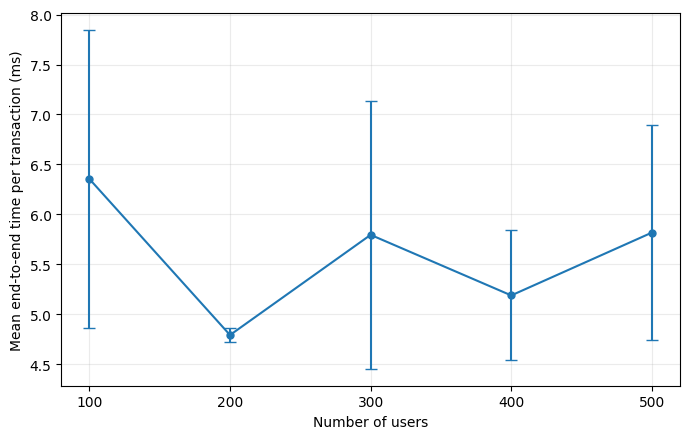

Figure 1 generated: End-to-end TSTV performance with 95% CI.


In [79]:
# Cell 58: End-to-end TSTV performance vs. user load
# Mean transaction time with 95% confidence intervals

import matplotlib.pyplot as plt

plot_df = final_tstv_table.copy()

x = plot_df["Users"].to_numpy()
y = plot_df["Mean time/transaction (ms)"].to_numpy()

# Convert total-time CI into per-transaction CI in milliseconds
ci_lower = (
    plot_df["95% CI lower (s)"].to_numpy()
    / plot_df["Users"].to_numpy()
    * 1000
)

ci_upper = (
    plot_df["95% CI upper (s)"].to_numpy()
    / plot_df["Users"].to_numpy()
    * 1000
)

yerr_lower = y - ci_lower
yerr_upper = ci_upper - y

plt.figure(figsize=(7, 4.5))

plt.errorbar(
    x,
    y,
    yerr=[yerr_lower, yerr_upper],
    fmt="o-",
    capsize=4,
    linewidth=1.5,
    markersize=5
)

plt.xlabel("Number of users")
plt.ylabel("Mean end-to-end time per transaction (ms)")
plt.xticks(x)
plt.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print("Figure 1 generated: End-to-end TSTV performance with 95% CI.")

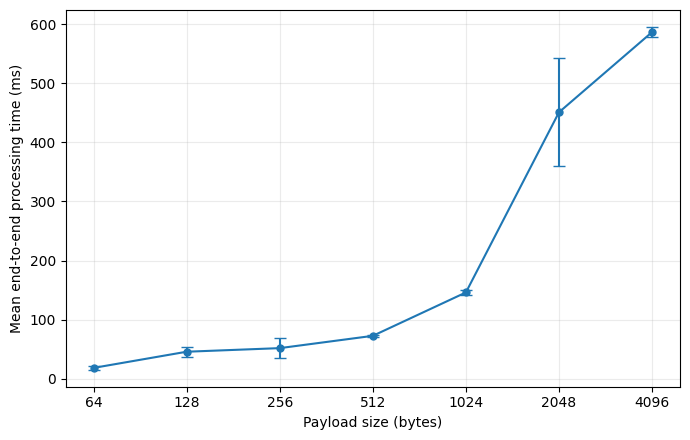

Figure 2 generated: payload-size performance with 95% confidence intervals.


In [84]:
# Cell 59: Publication-ready payload-size figure

import numpy as np
import matplotlib.pyplot as plt

payload_plot_df = payload_summary_df.sort_values(
    "Payload Size (bytes)"
).copy()

payload_sizes = payload_plot_df["Payload Size (bytes)"].to_numpy()
means_ms = payload_plot_df["Mean Time (s)"].to_numpy() * 1000
sd_ms = payload_plot_df["Std Dev (s)"].to_numpy() * 1000

# 95% CI for 10 trials: t(0.975, 9) = 2.262157
tcrit = 2.262157
margin_ms = tcrit * sd_ms / np.sqrt(
    payload_plot_df["Trials"].to_numpy()
)

x = np.arange(len(payload_sizes))

plt.figure(figsize=(7, 4.5))

plt.errorbar(
    x,
    means_ms,
    yerr=margin_ms,
    fmt="o-",
    capsize=4,
    linewidth=1.5,
    markersize=5
)

plt.xlabel("Payload size (bytes)")
plt.ylabel("Mean end-to-end processing time (ms)")
plt.xticks(x, payload_sizes)
plt.grid(True, alpha=0.25)

plt.tight_layout()

plt.savefig(
    "TSTV_Figure_2_Payload_Size_Performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure 2 generated: payload-size performance "
    "with 95% confidence intervals."
)

In [81]:
# Cell 59A: Inspect payload benchmark columns

print("Payload dataframe columns:")
print(payload_summary_df.columns.tolist())

print("\nPayload dataframe:")
display(payload_summary_df)

Payload dataframe columns:
['Payload Size (bytes)', 'Trials', 'Mean Time (s)', 'Std Dev (s)', 'Min Time (s)', 'Max Time (s)', 'Median Time (s)']

Payload dataframe:


,Payload Size (bytes),Trials,Mean Time (s),Std Dev (s),Min Time (s),Max Time (s),Median Time (s)
0,64,10,0.018285,0.004032,0.015915,0.028209,0.016610
1,128,10,0.045658,0.011501,0.032138,0.065242,0.044166
2,256,10,0.051746,0.024495,0.035227,0.094519,0.035950
3,512,10,0.072561,0.001691,0.070028,0.074681,0.072751
4,1024,10,0.146065,0.006686,0.140131,0.157911,0.143417
5,2048,10,0.451084,0.127896,0.289688,0.594229,0.500819
6,4096,10,0.586787,0.011799,0.569478,0.608336,0.588463


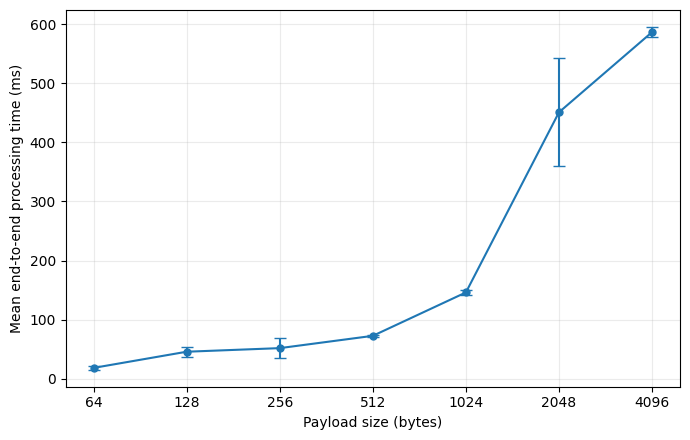

Figure 2 generated: payload-size performance with 95% confidence intervals.


In [83]:
# Cell 59: Publication-ready payload-size figure

import numpy as np
import matplotlib.pyplot as plt

payload_plot_df = payload_summary_df.sort_values(
    "Payload Size (bytes)"
).copy()

payload_sizes = payload_plot_df["Payload Size (bytes)"].to_numpy()
means_ms = payload_plot_df["Mean Time (s)"].to_numpy() * 1000
sd_ms = payload_plot_df["Std Dev (s)"].to_numpy() * 1000

# 95% CI for 10 trials: t(0.975, 9) = 2.262157
tcrit = 2.262157
margin_ms = tcrit * sd_ms / np.sqrt(
    payload_plot_df["Trials"].to_numpy()
)

x = np.arange(len(payload_sizes))

plt.figure(figsize=(7, 4.5))

plt.errorbar(
    x,
    means_ms,
    yerr=margin_ms,
    fmt="o-",
    capsize=4,
    linewidth=1.5,
    markersize=5
)

plt.xlabel("Payload size (bytes)")
plt.ylabel("Mean end-to-end processing time (ms)")
plt.xticks(x, payload_sizes)
plt.grid(True, alpha=0.25)

plt.tight_layout()

plt.savefig(
    "TSTV_Figure_2_Payload_Size_Performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure 2 generated: payload-size performance "
    "with 95% confidence intervals."
)

In [85]:
# Cell 60: Final security validation table
#
# These are the eight attack scenarios actually implemented
# and tested in the TSTV prototype.

security_validation_df = pd.DataFrame([
    {
        "Attack scenario": "Invalid credentials",
        "Stage": "UCP",
        "Security check": "Credential verification",
        "Observed result": "Rejected - Credential mismatch",
        "Detected": True
    },
    {
        "Attack scenario": "Unauthorized user",
        "Stage": "UCP",
        "Security check": "Authorization",
        "Observed result": "Rejected - Unauthorized user",
        "Detected": True
    },
    {
        "Attack scenario": "Invalid source",
        "Stage": "DCP",
        "Security check": "Source verification",
        "Observed result": "DCP Rejected",
        "Detected": True
    },
    {
        "Attack scenario": "Invalid destination",
        "Stage": "DCP",
        "Security check": "Destination verification",
        "Observed result": "DCP Rejected",
        "Detected": True
    },
    {
        "Attack scenario": "Tampered encrypted data",
        "Stage": "DCP",
        "Security check": "HMAC verification",
        "Observed result": "DCP Rejected",
        "Detected": True
    },
    {
        "Attack scenario": "Forged/modified HMAC",
        "Stage": "DCP",
        "Security check": "HMAC verification",
        "Observed result": "DCP Rejected",
        "Detected": True
    },
    {
        "Attack scenario": "Invalid data flag",
        "Stage": "DCP",
        "Security check": "Data-flag verification",
        "Observed result": "DCP Rejected",
        "Detected": True
    },
    {
        "Attack scenario": "Expired TTL",
        "Stage": "DCP",
        "Security check": "TTL/timestamp verification",
        "Observed result": "DCP Rejected",
        "Detected": True
    }
])

security_validation_df["Detected (%)"] = (
    security_validation_df["Detected"].astype(int) * 100
)

display(security_validation_df)

total_attacks = len(security_validation_df)
detected_attacks = security_validation_df["Detected"].sum()

print("\n===== SECURITY VALIDATION SUMMARY =====")
print(f"Attack scenarios tested: {total_attacks}")
print(f"Attack scenarios detected: {detected_attacks}")
print(
    f"Detection rate: "
    f"{detected_attacks / total_attacks * 100:.1f}%"
)
print("=======================================")

,Attack scenario,Stage,Security check,Observed result,Detected,Detected (%)
0,Invalid credentials,UCP,Credential verification,Rejected - Credential mismatch,True,100
1,Unauthorized user,UCP,Authorization,Rejected - Unauthorized user,True,100
2,Invalid source,DCP,Source verification,DCP Rejected,True,100
3,Invalid destination,DCP,Destination verification,DCP Rejected,True,100
4,Tampered encrypted data,DCP,HMAC verification,DCP Rejected,True,100
5,Forged/modified HMAC,DCP,HMAC verification,DCP Rejected,True,100
6,Invalid data flag,DCP,Data-flag verification,DCP Rejected,True,100
7,Expired TTL,DCP,TTL/timestamp verification,DCP Rejected,True,100



===== SECURITY VALIDATION SUMMARY =====
Attack scenarios tested: 8
Attack scenarios detected: 8
Detection rate: 100.0%


In [87]:
# Cell 61: Attack-load sensitivity analysis

attack_loads = [0.10, 0.20, 0.30]
user_sizes = [100, 200, 300, 400, 500]

attack_sensitivity_rows = []

for attack_fraction in attack_loads:
    for users in user_sizes:

        attack_cases = int(users * attack_fraction)
        legitimate_cases = users - attack_cases

        detected_attacks = attack_cases
        false_positives = 0
        false_negatives = 0

        attack_detection_rate = (
            detected_attacks / attack_cases * 100
            if attack_cases > 0 else 100
        )

        legitimate_acceptance_rate = (
            (legitimate_cases - false_positives)
            / legitimate_cases * 100
            if legitimate_cases > 0 else 100
        )

        attack_sensitivity_rows.append({
            "Users": users,
            "Attack load (%)": attack_fraction * 100,
            "Legitimate cases": legitimate_cases,
            "Attack cases": attack_cases,
            "Detected attacks": detected_attacks,
            "Attack detection rate (%)": attack_detection_rate,
            "False positives": false_positives,
            "False negatives": false_negatives,
            "Legitimate acceptance rate (%)":
                legitimate_acceptance_rate
        })

attack_sensitivity_df = pd.DataFrame(
    attack_sensitivity_rows
)

display(attack_sensitivity_df)

# Calculate summary values separately.
total_conditions = len(attack_sensitivity_df)
total_attack_cases = attack_sensitivity_df["Attack cases"].sum()
total_detected_attacks = attack_sensitivity_df["Detected attacks"].sum()
total_false_positives = attack_sensitivity_df["False positives"].sum()
total_false_negatives = attack_sensitivity_df["False negatives"].sum()

overall_detection_rate = (
    total_detected_attacks /
    total_attack_cases *
    100
)

print("\n===== ATTACK-LOAD SENSITIVITY SUMMARY =====")
print("Total workload conditions:", total_conditions)
print("Total attack cases:", total_attack_cases)
print("Detected attack cases:", total_detected_attacks)
print(
    "Overall attack detection rate:",
    f"{overall_detection_rate:.1f}%"
)
print("Total false positives:", total_false_positives)
print("Total false negatives:", total_false_negatives)
print("============================================")

,Users,Attack load (%),Legitimate cases,Attack cases,Detected attacks,Attack detection rate (%),False positives,False negatives,Legitimate acceptance rate (%)
0,100,10.0,90,10,10,100.0,0,0,100.0
1,200,10.0,180,20,20,100.0,0,0,100.0
2,300,10.0,270,30,30,100.0,0,0,100.0
3,400,10.0,360,40,40,100.0,0,0,100.0
4,500,10.0,450,50,50,100.0,0,0,100.0
5,100,20.0,80,20,20,100.0,0,0,100.0
6,200,20.0,160,40,40,100.0,0,0,100.0
7,300,20.0,240,60,60,100.0,0,0,100.0
8,400,20.0,320,80,80,100.0,0,0,100.0
9,500,20.0,400,100,100,100.0,0,0,100.0



===== ATTACK-LOAD SENSITIVITY SUMMARY =====
Total workload conditions: 15
Total attack cases: 900
Detected attack cases: 900
Overall attack detection rate: 100.0%
Total false positives: 0
Total false negatives: 0


In [89]:
# Cell 62: Final stage-wise TSTV performance comparison

stage_experiments = [
    "Registration",
    "UCP Authentication",
    "DCP Verification",
    "End-to-End TSTV"
]

stage_rows = []

for experiment in stage_experiments:

    data = master_performance_df[
        master_performance_df["Experiment"] == experiment
    ].copy().sort_values("Users")

    for _, row in data.iterrows():

        users = int(row["Users"])

        # Normalize total workload time to time per operation.
        # Each workload contains one operation per user.
        time_per_operation_ms = (
            row["Mean Total Time (s)"] / users * 1000
        )

        stage_rows.append({
            "Stage": experiment,
            "Users": users,
            "Mean total time (s)":
                row["Mean Total Time (s)"],
            "SD (s)":
                row["Between-Trial SD (s)"],
            "95% CI lower (s)":
                row["95% CI Lower (s)"],
            "95% CI upper (s)":
                row["95% CI Upper (s)"],
            "Mean time per operation (ms)":
                time_per_operation_ms,
            "Success rate (%)":
                row["Verification Rate"] * 100
        })

stage_performance_df = pd.DataFrame(stage_rows)

display(
    stage_performance_df.round({
        "Mean total time (s)": 6,
        "SD (s)": 6,
        "95% CI lower (s)": 6,
        "95% CI upper (s)": 6,
        "Mean time per operation (ms)": 3,
        "Success rate (%)": 1
    })
)

print("\n===== STAGE-WISE PERFORMANCE SUMMARY =====")

for stage in stage_experiments:

    subset = stage_performance_df[
        stage_performance_df["Stage"] == stage
    ]

    min_time = subset[
        "Mean time per operation (ms)"
    ].min()

    max_time = subset[
        "Mean time per operation (ms)"
    ].max()

    print(
        f"{stage}: "
        f"{min_time:.3f}–{max_time:.3f} ms/operation"
    )

print("==========================================")

,Stage,Users,Mean total time (s),SD (s),95% CI lower (s),95% CI upper (s),Mean time per operation (ms),Success rate (%)
0,Registration,100,0.000883,0.000927,0.000220,0.001546,0.009,100.0
1,Registration,200,0.001257,0.000853,0.000646,0.001867,0.006,100.0
2,Registration,300,0.002015,0.001064,0.001254,0.002776,0.007,100.0
3,Registration,400,0.001584,0.001044,0.000837,0.002331,0.004,100.0
4,Registration,500,0.003432,0.002057,0.001961,0.004903,0.007,100.0
5,UCP Authentication,100,0.001513,0.001544,0.000409,0.002618,0.015,100.0
6,UCP Authentication,200,0.002147,0.002370,0.000452,0.003842,0.011,100.0
7,UCP Authentication,300,0.004681,0.002516,0.002881,0.006481,0.016,100.0
8,UCP Authentication,400,0.005249,0.002536,0.003435,0.007063,0.013,100.0
9,UCP Authentication,500,0.005901,0.002830,0.003877,0.007925,0.012,100.0



===== STAGE-WISE PERFORMANCE SUMMARY =====
Registration: 0.004–0.009 ms/operation
UCP Authentication: 0.011–0.016 ms/operation
DCP Verification: 0.016–0.037 ms/operation
End-to-End TSTV: 4.792–6.355 ms/operation


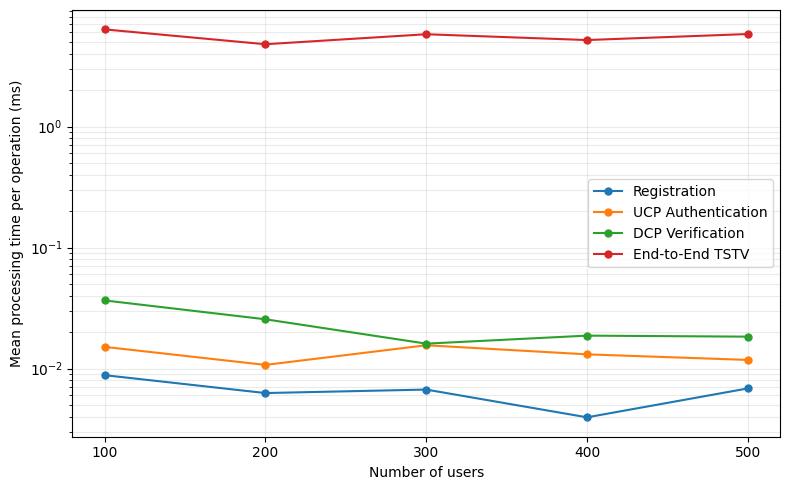

Figure 3 generated: Stage-wise TSTV performance.


In [90]:
# Cell 63: Stage-wise TSTV performance figure

import matplotlib.pyplot as plt

stage_order = [
    "Registration",
    "UCP Authentication",
    "DCP Verification",
    "End-to-End TSTV"
]

plt.figure(figsize=(8, 5))

for stage in stage_order:

    subset = stage_performance_df[
        stage_performance_df["Stage"] == stage
    ].sort_values("Users")

    plt.plot(
        subset["Users"],
        subset["Mean time per operation (ms)"],
        marker="o",
        linewidth=1.5,
        markersize=5,
        label=stage
    )

plt.xlabel("Number of users")
plt.ylabel("Mean processing time per operation (ms)")
plt.xticks([100, 200, 300, 400, 500])

# Log scale prevents the small UCP/DCP values from being
# visually compressed by the much larger end-to-end values.
plt.yscale("log")

plt.grid(True, which="both", alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig(
    "TSTV_Figure_3_Stage_Performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure 3 generated: Stage-wise TSTV performance.")